# Analiza historycznych cen smartfonów na Amazon

Przeanalizowałem, jak smartfony Apple, Samsung i Google tracą wartość z czasem na rynku wtórnym Amazon US. Dane cenowe pobrałem przez płatne API Keepa. Zbiór obejmuje 63 modele smartfonów i około 878 000 tygodniowych rekordów cenowych z lat 2019-2026. Badałem też dane sprzedażowe.

Pytania analityczne:

- Czy smartfony różnych marek tracą wartość w zauważalnie innym tempie?
- Kiedy najlepiej kupić używany smartfon?
- Które modele tracą wartość najszybciej i jak nisko może spaść ich cena?
- Czy w sprzedaży telefonów widać wzorce sezonowe?

---
## Importy

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid')

---
## Ładowanie danych

### Historia cen

Główny zbiór danych zawiera po jednym wierszu na każdy ASIN (każdy produkt, np. Iphone 13 Red 64 GB itd.) na tygodniowy snapshot cenowy. Zacznynam od wczytania danych i zbadania ich struktury.

In [2]:
data_folder = './data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

878,267 rows, 16 columns


,asin,storage_gb,color,product_grade,submodel_name,brand,generation_name,premiere_date,datetime,new_price,amazon,used_price,list_price,sales_rank,count_new,count_used
0,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-02 15:36:00,5.69,5.69,NaN,NaN,NaN,1.0,NaN
1,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-09 18:36:00,5.51,5.51,NaN,NaN,13995.0,NaN,NaN
2,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-23 10:36:00,5.69,5.69,NaN,NaN,8232.0,NaN,NaN
3,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-24 07:36:00,5.29,5.29,NaN,5.69,5468.0,NaN,NaN
4,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-08-06 09:32:00,5.69,5.69,NaN,NaN,3205.0,NaN,NaN


Rzut oka na kluczowe kolumny i ich typy:

In [3]:
df[['brand', 'generation_name', 'product_grade', 'new_price', 'datetime', 'premiere_date']].dtypes

brand                  str
generation_name        str
product_grade          str
new_price          float64
datetime               str
premiere_date          str
dtype: object

Sprawdzam brakujące wartości w zbiorze:

In [4]:
df.isnull().sum()

asin                    0
storage_gb          19710
color                   0
product_grade           0
submodel_name           0
brand                   0
generation_name         0
premiere_date           0
datetime                0
new_price               0
amazon             816489
used_price         727802
list_price         868356
sales_rank         461927
count_new          542322
count_used         757122
dtype: int64

Kilka rzeczy od razu rzuca się w oczy:

- Wartości `new_price` są podejrzanie małe. Po sprawdzeniu dokumentacji Keepa okazało się, że ceny w eksporcie CSV są podzielone przez 100, więc mnożę je przez 100, żeby uzyskać właściwe wartości.
- `datetime` i `premiere_date` to stringi, co może powodować pewne problemy - będę je konwertował na datetime.
- `premiere_date` to data rozpoczęcia śledzenia przez Keepa, która nie pokrywa się z faktyczną datą premiery rynkowej. Do analizy spadku wartości potrzebuję prawdziwej daty premiery, więc pobiorę te daty z oficjalnych danych z sieci.
- Duże ilości brakujących wartości w `amazon`, `used_price`, `list_price`, `sales_rank` są oczekiwane i nie wpłyną na analizę, bo tutaj skupiam się na `new_price`.

Sprawdzam też ilości danych, jakie mamy w zbiorze i dodatkowo różnicuję je pod kątem klasy produktu (product_grade).

In [5]:
print(df['brand'].value_counts())
print()
print(df['product_grade'].value_counts())

apple_check_df = df[df['brand'] == 'Apple']
print(apple_check_df['product_grade'].value_counts())

samsung_check_df = df[df['brand'] == 'Samsung']
print(samsung_check_df['product_grade'].value_counts())

google_check_df = df[df['brand'] == 'Google']
print(google_check_df['product_grade'].value_counts())

brand
Apple      616537
Samsung    190786
Google      70944
Name: count, dtype: int64

product_grade
Renewed            533338
New                223114
Renewed Premium    109511
Unlocked            12304
Name: count, dtype: int64
product_grade
Renewed            470681
Renewed Premium    109496
New                 24056
Unlocked            12304
Name: count, dtype: int64
product_grade
New        170588
Renewed     20198
Name: count, dtype: int64
product_grade
Renewed            42459
New                28470
Renewed Premium       15
Name: count, dtype: int64


Apple to jedyna marka z klasą Renewed Premium (Google też je posiada, ale to jedynie 15 takich przypadków, więc warto je pominąć) i zdecydowana większość rekordów Apple to telefony inne niż New. Zaledwie około 3,8% to oferty z nowymi smartfonami. Widać wyraźnie, że rynek Amazon skupia się głównie na używanych iPhone'ach.

Samsung i Google mają tylko standardową klasę Renewed, ale za to znacznie więcej listingów klasy New. Różnica jest spora: w przypadku Samsunga aż 90% listingów to nowe telefony, a Google sprzedawany jest jako New w około 40% przypadków. To dość istotna różnica, którą trzeba mieć na uwadze.

### Oficjalne ceny premierowe w dolarach (USD)

Na początku korzystałem z pierwszej ceny pobranej z historii Keepa, ale ostatecznie stworzyłem tabelę referencyjną z datami premier i cenami smartfonów ręcznie na podstawie oficjalnych danych.

Jako cenę premierową przyjąłem średnią ze wszystkich wariantów pamięci (np. cena iPhone 16 Pro to średnia cen wariantów 128GB, 256GB, 512GB, 1TB). Zamiast daty rozpoczęcia śledzenia przez Keepa, która bywa opóźniona o kilka miesięcy, używam `official_premiere_date` z tej tabeli jako punktu odniesienia dla wszystkich obliczeń, 

In [6]:
original_launch_ref = pd.read_csv('./data/official_launch_prices.csv')

print(f"{original_launch_ref.shape[0]} submodels")
original_launch_ref.head(10)

64 submodels


,submodel_name,official_launch_price,official_premiere_date
0,iPhone 11,766,2019-09-20
1,iPhone 11 Pro,1166,2019-09-20
2,iPhone 11 Pro Max,1266,2019-09-20
3,iPhone 12 Mini,766,2020-11-13
4,iPhone 12,849,2020-10-23
5,iPhone 12 Pro,1099,2020-10-23
6,iPhone 12 Pro Max,1199,2020-11-13
7,iPhone 13,929,2021-09-24
8,iPhone 13 Mini,829,2021-09-24
9,iPhone 13 Pro,1224,2021-09-24


### Dane sprzedażowe

Ten plik zawiera dane szacunkowe sprzedaży z Keepa. Przejrzyjmy dane, z którymi mamy do czynienia.

In [7]:
ms_df = pd.read_csv('./data/monthly_sold_full.csv')

print(f"{ms_df.shape[0]} rows, {ms_df.shape[1]} columns")
ms_df.head()

18489 rows, 8 columns


,asin,product_grade,submodel_name,brand,generation_name,premiere_date,datetime,monthly_sold
0,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2023-10-20 07:04:00,50
1,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2023-11-28 13:34:00,100
2,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-01 08:42:00,50
3,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-01 18:16:00,100
4,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-02 14:56:00,50


UWAGA: Wartości `monthly_sold` nie są precyzyjnymi wolumenami sprzedażowymi. Keepa przypisuje każdemu ASIN-owi przedział sprzedaży: `50` oznacza 50-99 sztuk, `100` oznacza 100-499 i tak dalej. Nie jestem w stanie dokładnie obliczyć wolumenu sprzedaży, więc traktuję te dane wyłącznie jako wskaźnik względnej aktywności rynkowej.

In [8]:
ms_df['monthly_sold'].value_counts().sort_index().head(15)

monthly_sold
-1        547
 50      2414
 100     3497
 200     3129
 300     2644
 400     2394
 500     1875
 1000     999
 2000     546
 3000     242
 4000     110
 5000      47
 6000      10
 7000      21
 8000      14
Name: count, dtype: int64

Od razu zauważam wartości '-1' w danych, więc warto je odfiltrować.

In [9]:
ms_df = ms_df[ms_df['monthly_sold'] >= 0]
ms_df['monthly_sold'].value_counts().sort_index().head(15)

monthly_sold
50      2414
100     3497
200     3129
300     2644
400     2394
500     1875
1000     999
2000     546
3000     242
4000     110
5000      47
6000      10
7000      21
8000      14
Name: count, dtype: int64

Gotowe!

In [10]:
ms_df.isnull().sum()

asin               0
product_grade      0
submodel_name      0
brand              0
generation_name    0
premiere_date      0
datetime           0
monthly_sold       0
dtype: int64

---
## Pipeline cenowy

### Krok 1: Połączenie z oficjalnymi cenami premierowymi

Łączę historię cen z tabelą referencyjną po kolumnie `submodel_name`. To pozwala dodać `official_launch_price` i `official_premiere_date`, a przy okazji konwertuję kolumny z datami na obiekty datetime, co pozwoli uniknąć problemów dalej.

In [11]:
df = df.merge(original_launch_ref, on='submodel_name')

df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Rows after merge: {df.shape[0]}")
df[['submodel_name', 'brand', 'datetime', 'official_premiere_date', 'official_launch_price']].head()

Rows after merge: 878267


,submodel_name,brand,datetime,official_premiere_date,official_launch_price
0,iPhone 11,Apple,2021-07-02 15:36:00,2019-09-20,766
1,iPhone 11,Apple,2021-07-09 18:36:00,2019-09-20,766
2,iPhone 11,Apple,2021-07-23 10:36:00,2019-09-20,766
3,iPhone 11,Apple,2021-07-24 07:36:00,2019-09-20,766
4,iPhone 11,Apple,2021-08-06 09:32:00,2019-09-20,766


### Krok 2: Kluczowe metryki

Trzy kolumny napędzają każdy wykres spadku wartości:

- **`days_since_launch`**: liczba dni między snapshotem cenowym a oficjalną datą premiery. Odfiltrowuję wiersze z wartością 0 lub ujemną.
- **`NEW`**: cena w dolarach. Keepa przechowuje ceny podzielone przez 100, więc mnożę przez 100 (np. `5.69` to `$569.00`).
- **`price_pct_of_launch`**: `NEW / official_launch_price * 100`. To główna metryka w tej części analizy. 100% oznacza cenę równą cenie premierowej, 50% to utrata połowy wartości. Zdarzają się wartości powyżej 100%, ale to wynika z użycia średniej jako ceny premierowej.
- **`days_rounded`**: dni zaokrąglone do najbliższej 7. Bez tego ASIN-y z nieco innymi datami snapshotów (np. 1-2 dni później) tworzą oddzielne linie na wykresach Seaborn zamiast jednej płynnej krzywej. Zaokrąglenie do tygodniowych kubełków eliminuje ten problem i scala dane.

Dodaję także jeszcze jedną kolumnę na potrzeby przyszłej agregacji:
- **`tier`**: wyodrębniony przez usunięcie nazwy generacji z nazwy submodelu. Na przykład 'iPhone 13 Pro Max' staje się 'Pro Max', a 'iPhone 13' staje się 'Base'.

Poniżej wprowadzam te dane w kodzie.

In [12]:
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]

df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)

#calculating the price percent of the official launch price + days_rounded as days rounded to the nearest 7
df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7

#stripping the generation name from the submodel and then fetching 'Base' wherever it ends up empty (these are our base models :)))

df['tier'] = [
    submodel.replace(generation, '').strip()
    for submodel, generation in zip(df['submodel_name'], df['generation_name'])
]
df['tier'] = df['tier'].replace('', 'Base')

print(f"Rows after filtering pre-launch: {df.shape[0]:,}")
df[['submodel_name', 'tier', 'days_since_launch', 'NEW', 'price_pct_of_launch']].head(8)

Rows after filtering pre-launch: 878,193


,submodel_name,tier,days_since_launch,NEW,price_pct_of_launch
0,iPhone 11,Base,651,569.0,74.3
1,iPhone 11,Base,658,551.0,71.9
2,iPhone 11,Base,672,569.0,74.3
3,iPhone 11,Base,673,529.0,69.1
4,iPhone 11,Base,686,569.0,74.3
5,iPhone 11,Base,687,529.0,69.1
6,iPhone 11,Base,701,569.0,74.3
7,iPhone 11,Base,704,529.0,69.1


Szybka weryfikacja ekstrakcji tierów:

In [13]:
df.groupby('brand')['tier'].value_counts()

brand    tier    
Apple    Base        165423
         Pro Max     158739
         Pro         146881
         Mini        108160
         Plus         37334
Google   Pro          33856
         Base         28076
         a             7189
         Pro Fold      1140
         Pro XL         641
Samsung  Base         78629
         Ultra        51109
         +            34036
         FE           26202
         Edge           778
Name: count, dtype: int64

Wszystko wygląda w porządku. Edge i Pro Fold / Pro XL mają mało danych, ale to nowe / eksperymentalne modele, więc mnie to nie dziwi.

### Krok 3: Sprawdzenie klas produktów

Zanim przejdę do wykresów, chcę sprawdzić, czy ceny w zależności od klasy produktu rzeczywiście się różnią.

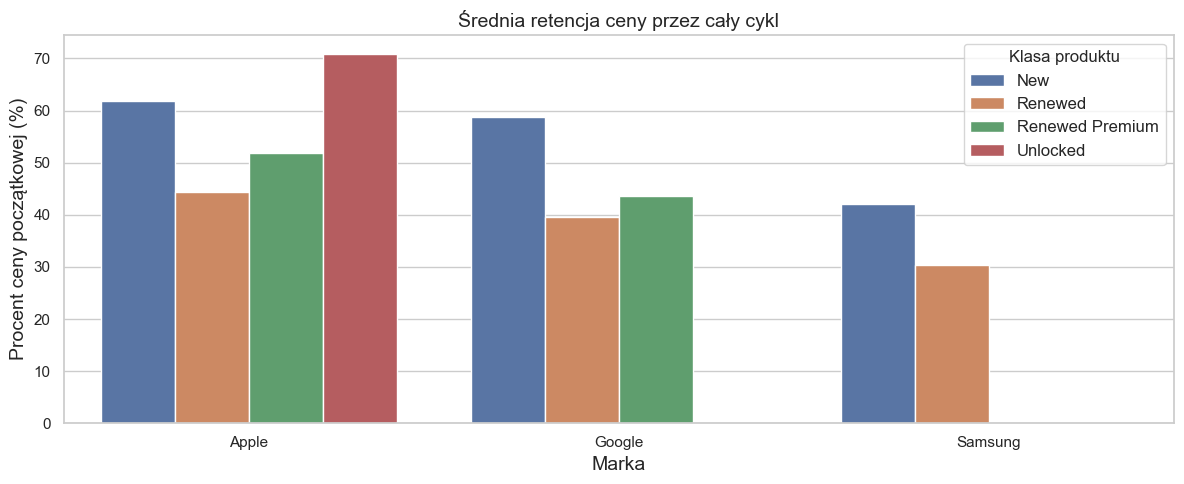

In [14]:
grade_price_df = df.groupby(['brand', 'product_grade'])['price_pct_of_launch'].mean().round(1).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=grade_price_df, x='brand', y='price_pct_of_launch', hue='product_grade', ax=ax)
ax.set_title('Średnia retencja ceny przez cały cykl', fontsize=14)
ax.set_xlabel('Marka', fontsize=14)
ax.set_ylabel('Procent ceny początkowej (%)', fontsize=14)
ax.legend(title='Klasa produktu', fontsize=12)
plt.tight_layout()
plt.show()


Różnica jest widoczna we wszystkich trzech markach:

- Apple: New utrzymuje 61,8% vs Renewed 44,4%. To 17 punktów procentowych.
- Samsung: New 42,0% vs Renewed 30,4%, różnica 12 pp.
- Google: New 58,8% vs Renewed 39,6%, różnica 19 pp.

Różnice są wyraźne, ale wyfiltrowanie klasy New oznaczałoby utratę około 90% danych Samsunga i 40% danych Google. W tej sytuacji nie mam zamiaru tego robić, ale będę pamiętać o tej różnicy przy interpretacji wyników.

---
# Analiza spadku wartości

Każdy wykres poniżej pokazuje cenę jako procent oficjalnej ceny premierowej w czasie. 100% oznacza cenę równą cenie premierowej, 50% to utrata połowy wartości. Oś X pokazuje dni od premiery, dzięki czemu modele można porównywać w tym samym momencie cyklu niezależnie od daty wydania.

## Oficjalne ceny premierowe

Zanim przejdę do spadku wartości, warto zobaczyć, ile produkty kosztują na starcie.

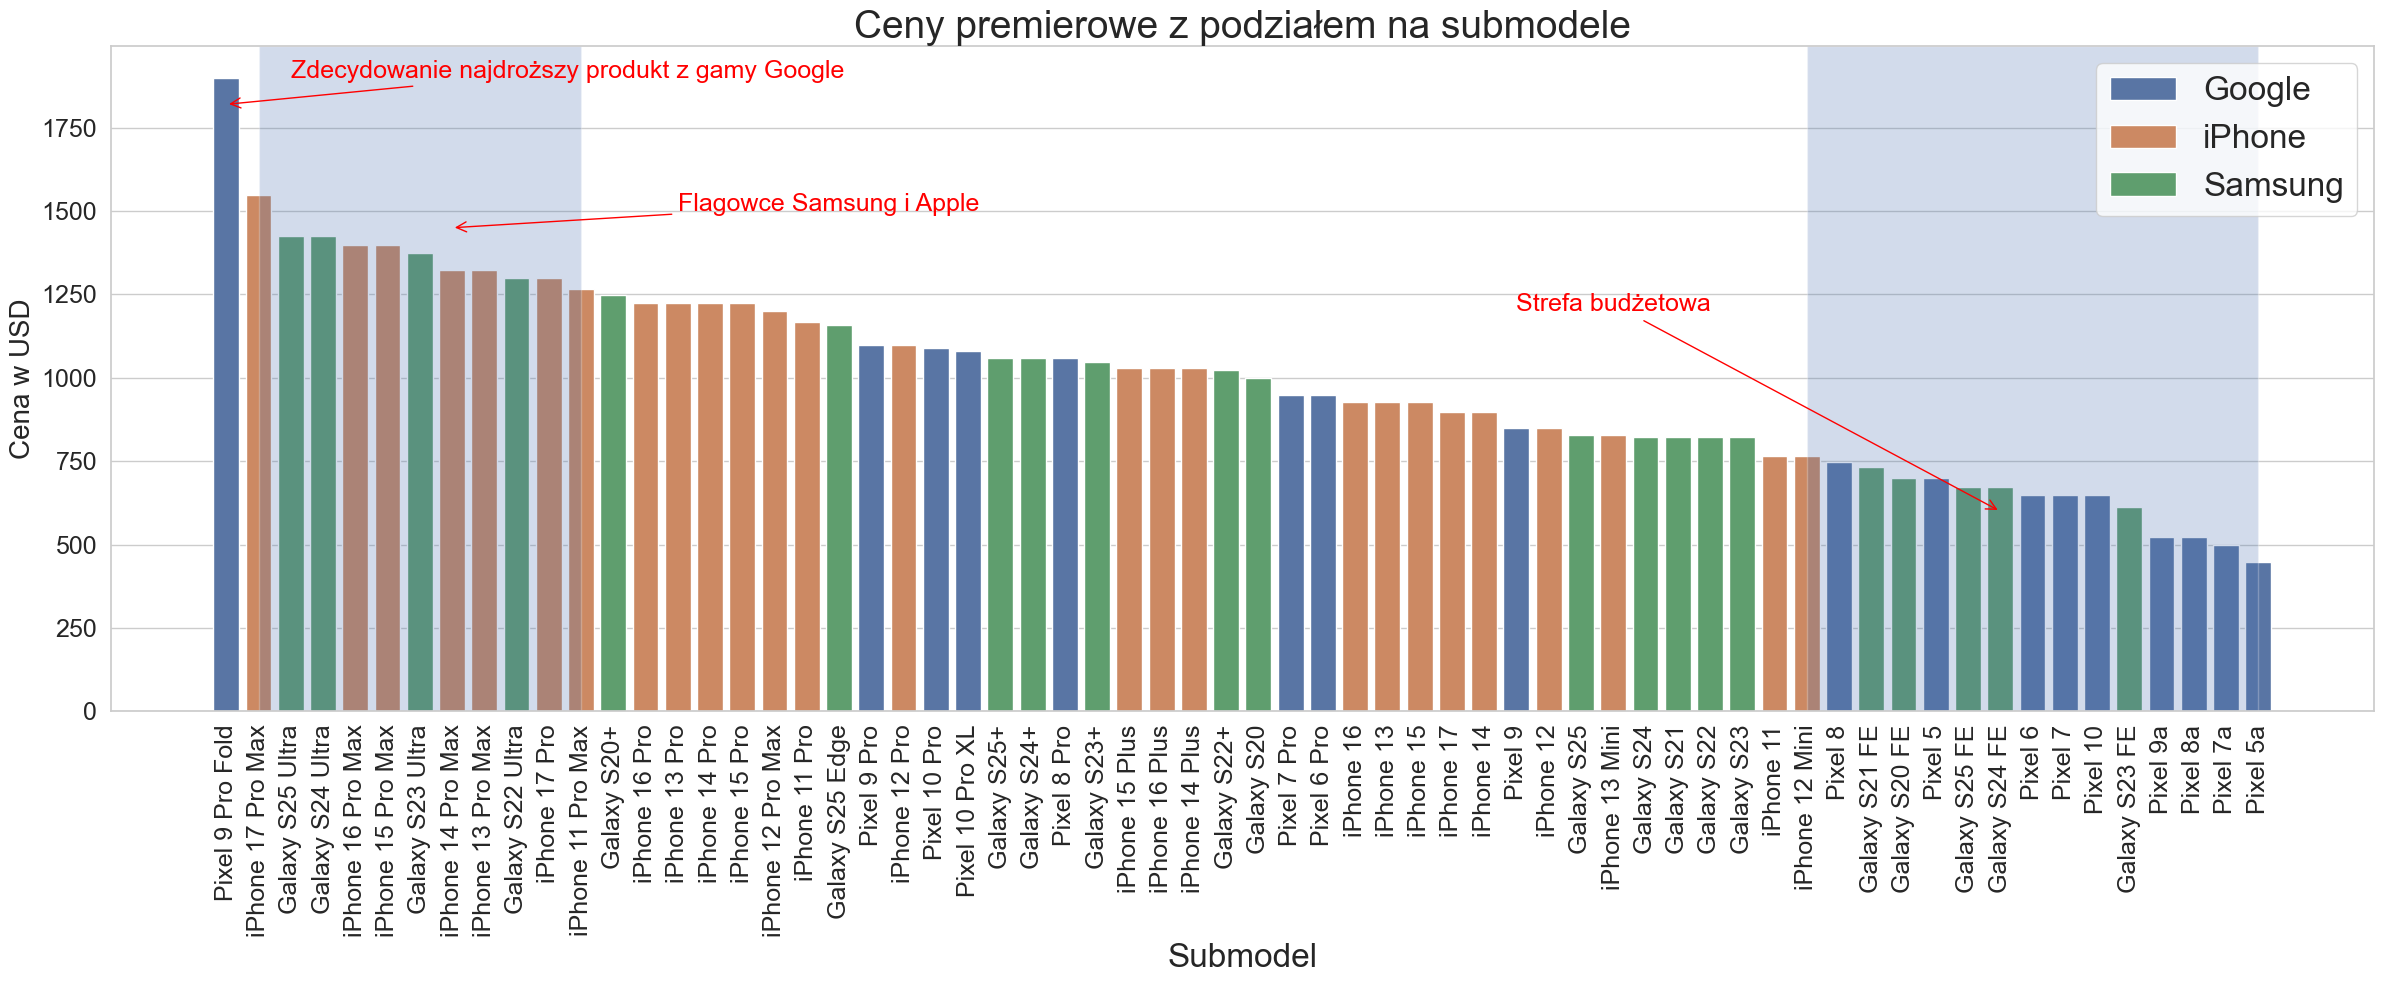

In [15]:
gen_lookup = df[['submodel_name', 'generation_name', 'brand']].drop_duplicates()
launch_ref = original_launch_ref.copy().merge(gen_lookup, on='submodel_name', how='left')

#Here I'm also adding the tier as it will be used later
#By tier I mean Base (as in base iPhone 11, Samsung Galaxy S23 etc.), Pro, Pro Max, +, Ultra etc.
launch_ref['tier'] = [
    submodel.replace(str(generation), '').strip()
    for submodel, generation in zip(launch_ref['submodel_name'], launch_ref['generation_name'])
]
launch_ref['tier'] = launch_ref['tier'].replace('', 'Base')

#converting the date to a pandas datetime format
launch_ref['official_premiere_date'] = pd.to_datetime(launch_ref['official_premiere_date'])

#brand name fix for Pixel and Galaxy
launch_ref['brand'] = launch_ref['submodel_name'].str.split().str[0].replace(
    ['Pixel', 'Galaxy'], ['Google', 'Samsung'])

#sorting values based on their launch price in USD
launch_ref = launch_ref.sort_values('official_launch_price', ascending=False)

plt.subplots(figsize=(24, 10))
sns.barplot(data=launch_ref, x='submodel_name', y='official_launch_price', hue='brand')
plt.legend(loc='upper right', fontsize = 24)
plt.xticks(rotation = 90, fontsize = 18),
plt.yticks(fontsize = 18)
plt.xlabel('Submodel', fontsize = 24)
plt.ylabel('Cena w USD', fontsize = 20)
plt.title('Ceny premierowe z podziałem na submodele', fontsize = 28)

plt.annotate(
    text = 'Zdecydowanie najdroższy produkt z gamy Google',
    xy = (0, 1820),
    xytext = (2, 1900),
    fontsize = 18,
    color = 'red',
    arrowprops = dict(arrowstyle = '->', color = 'red')
)

plt.axvspan(
    xmin = 49,
    xmax = 63,
    alpha = 0.25
)

plt.annotate(
    text = 'Strefa budżetowa',
    xy = (55, 600),
    xytext = (40, 1200),
    fontsize = 18,
    color = 'red',
    arrowprops = dict(arrowstyle = '->', color = 'red')
)

plt.axvspan(
    xmin = 1,
    xmax = 11,
    alpha = 0.25
)


plt.annotate(
    text = 'Flagowce Samsung i Apple',
    xy = (7, 1450),
    xytext = (14, 1500),
    fontsize = 18,
    color = 'red',
    arrowprops = dict(arrowstyle = '->', color = 'red')
)

plt.tight_layout()
plt.show()

Uwaga: w gamie Google pojawia się model Pro Fold, który zajmuje pierwsze miejsce pod względem ceny (1799 USD). Najlepiej traktować go jednak jako model eksperymentalny a nie flagowca. Jego cena odzwierciedla złożoność i elastyczny wyświetlacz, ale są tam też pewne kompromisy pod kątem osiągów względem flagowców. Prawdziwym flagowcem Google pod względem parametrów jest Pixel Pro. 

W przeciwieństwie do Pro Folda, iPhone Pro Max i Samsung Galaxy Ultra to bezsporne flagowce w swoich markach.

Poniżej porównanie cen premierowych w czasie, z podziałem na modele bazowe i flagowce.

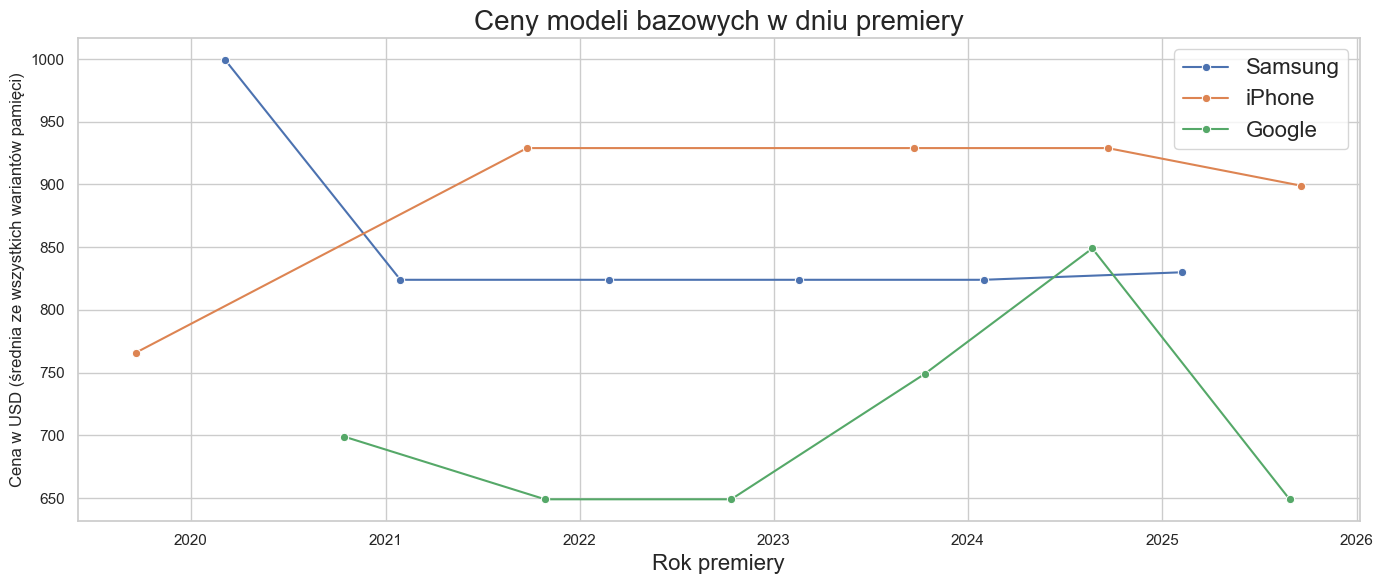

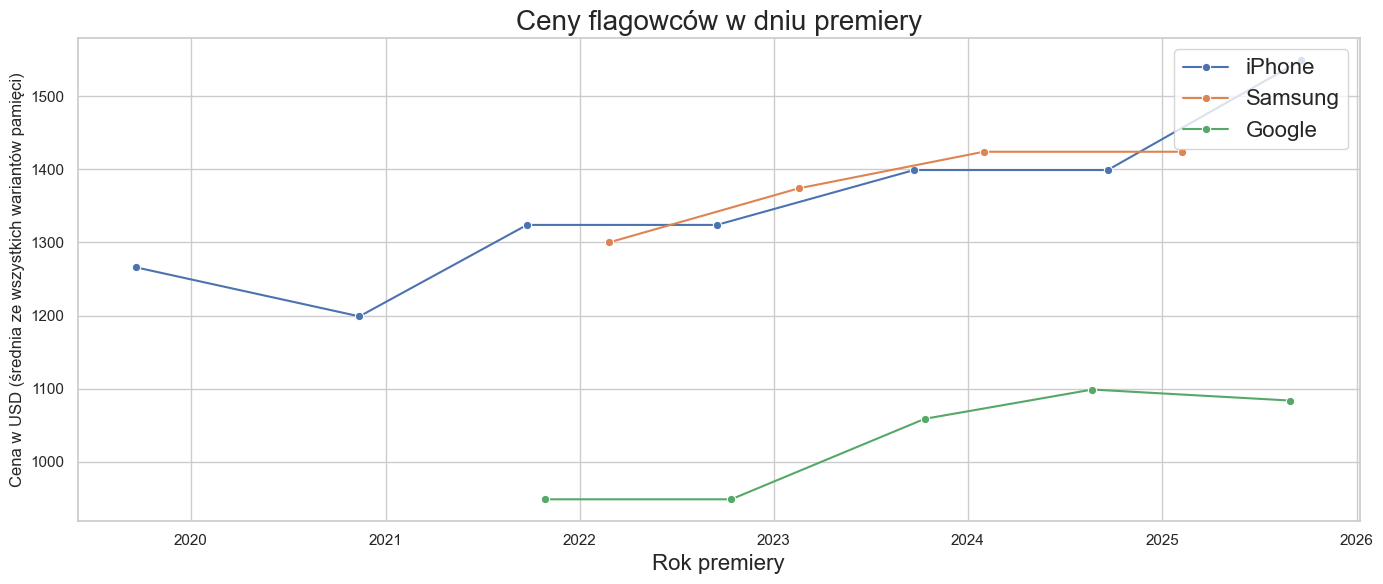

In [16]:
base_launch_ref = launch_ref[launch_ref['tier'] == 'Base']
flagship_launch_ref = launch_ref[
    (launch_ref['tier'] == 'Pro Max') |
    (launch_ref['tier'] == 'Ultra') |
    (launch_ref['tier'] == 'Pro XL') |
    ((launch_ref['tier'] == 'Pro') & (launch_ref['brand'] == 'Google'))
]

plt.subplots(figsize=(14, 6))
sns.lineplot(data=base_launch_ref, x='official_premiere_date', y='official_launch_price',
    hue='brand', marker='o')
plt.legend(loc='upper right', fontsize=16)
plt.xlabel('Rok premiery', fontsize=16)
plt.ylabel('Cena w USD (średnia ze wszystkich wariantów pamięci)', fontsize=12)
plt.title('Ceny modeli bazowych w dniu premiery', fontsize=20)
plt.tight_layout()
plt.show()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=flagship_launch_ref, x='official_premiere_date', y='official_launch_price',
    hue='brand', marker='o')
plt.legend(loc='upper right', fontsize=16)
plt.xlabel('Rok premiery', fontsize=16)
plt.ylabel('Cena w USD (średnia ze wszystkich wariantów pamięci)', fontsize=12)
plt.title('Ceny flagowców w dniu premiery', fontsize=20)
plt.tight_layout()

plt.show()

Google konsekwentnie pozycjonuje się jako najbardziej budżetowa marka. W obu tierach smartfony Google są średnio około 20% tańsze od konkurencji.

Samsung i Apple są bezpośrednimi rywalami w górnym segmencie rynku. Modele bazowe Apple są zazwyczaj około 10% droższe niż bazowe Samsungi, ale ta różnica znika na poziomie premium, gdzie modele Ultra Samsunga są wycenione niemal identycznie jak warianty Pro Max Apple'a.

---
## Wszystkie marki razem (modele bazowe)

Zaczynam od najbardziej ogólnego porównania uśrednionego spadku wartości dla wszystkich bazowych modeli (np. iPhone 11, iPhone 12 itd.) danej marki.

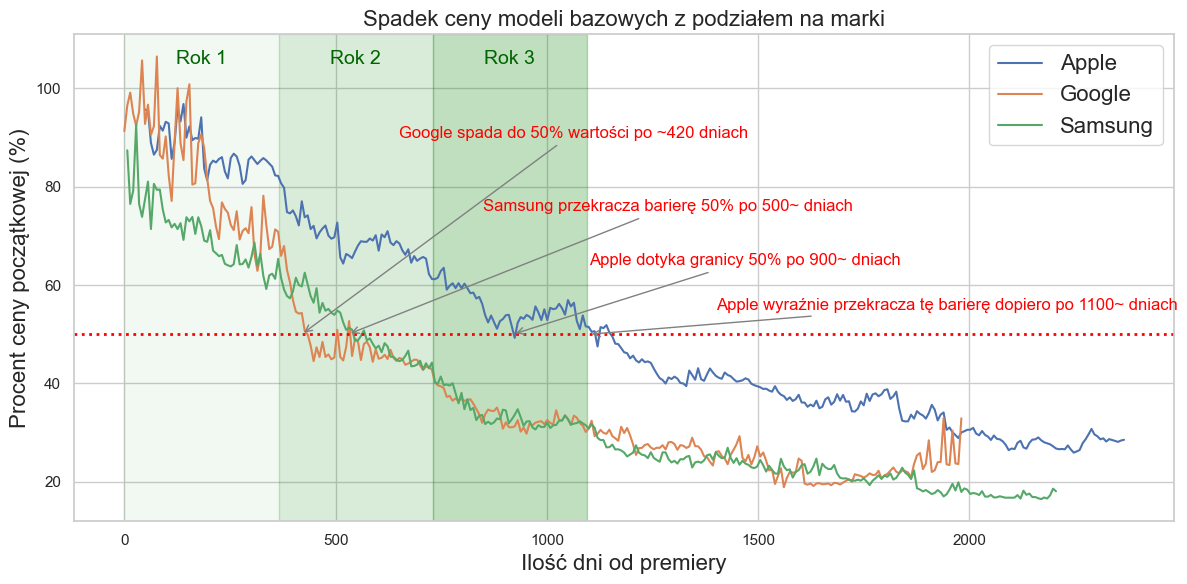

In [17]:
base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch', hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Spadek ceny modeli bazowych z podziałem na marki', fontsize=16)
ax.set_xlabel('Ilość dni od premiery', fontsize=16)
ax.set_ylabel('Procent ceny początkowej (%)', fontsize=16)
plt.legend(loc = 'upper right', fontsize=16)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Rok 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Rok 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Rok 3', fontsize=14, color='darkgreen', ha='center')

plt.annotate('Samsung przekracza barierę 50% po 500~ dniach', xy=(530, 50), xytext=(850, 75),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red')
plt.annotate('Apple dotyka granicy 50% po 900~ dniach', xy=(920, 50), xytext=(1100, 64),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red')
plt.annotate('Apple wyraźnie przekracza tę barierę dopiero po 1100~ dniach', xy=(1100, 50), xytext=(1400, 55),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red')
plt.annotate('Google spada do 50% wartości po ~420 dniach', xy=(420, 50), xytext=(650, 90),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red')

plt.savefig('wykres1.png', dpi=300, bbox_inches='tight')
plt.show()

iPhone'y jako ostatnie spadają do 50% ceny premierowej, po raz pierwszy osiągając ten próg po około 900 dniach od premiery, a wyraźnie przekraczając ją po około 1100 dniach. 

Samsung osiąga ten poziom po około 500 dniach, Google po około 420 dniach. 

Apple ma też najwyższe ceny minimalne, które stabilizują się na poziomie 26-28% ceny premierowej po około 2000 dniach. Smartfony marki Samsung spadają do 16-17% a Google do około 20% ceny początkowej.

### Weryfikacja statystyczna

Wykres sugeruje wyraźne różnice między markami. Postanowiłem przeprowadzić testy statystyczne, żeby potwierdzić, że nie wynikają z losowości.

Wybór testu zależy od rozkładu danych. ANOVA zakłada rozkład normalny w każdej grupie. Jeśli dane nie będą miały rozkładu normalnego, użyję odpowiednika nieparametrycznego, czyli testu Kruskala-Wallisa.

Zaczynam od testu normalności.

In [18]:
from scipy.stats import normaltest

for brand in df['brand'].unique():
    group = df[df['brand'] == brand]['price_pct_of_launch'].dropna()
    stat, p = normaltest(group)
    print(f"{brand}: p={p:.4f}")

Apple: p=0.0000
Google: p=0.0000
Samsung: p=0.0000


Hipoteza zerowa: rozkład jest normalny.

Hipoteza alternatywna: rozkład nie jest normalny.

---

Wartości p poniżej 0,05 pozwalają odrzucić hipotezę zerową, co oznacza, że rozkłady nie są normalne.

Przechodzę zatem do testu Kruskala-Wallisa zamiast ANOVY.

In [19]:
from scipy.stats import kruskal

rng = 42 #the same seed for all samples

apple = df[['price_pct_of_launch', 'brand']][df['brand'] == 'Apple'].sample(1000, random_state = rng).reset_index()
google = df[['price_pct_of_launch', 'brand']][df['brand'] == 'Google'].sample(1000, random_state = rng).reset_index()
samsung = df[['price_pct_of_launch', 'brand']][df['brand'] == 'Samsung'].sample(1000, random_state = rng).reset_index()

sampled_df = pd.concat([apple, google, samsung])

kruskal_result = kruskal(
    apple['price_pct_of_launch'],
    google['price_pct_of_launch'],
    samsung['price_pct_of_launch']
)
print(kruskal_result)



KruskalResult(statistic=np.float64(98.17696842997599), pvalue=np.float64(4.798905307089776e-22))


Wartość p wynosi 4.79...e-22, czyli praktycznie zero, znacznie poniżej 0,05.

Oznacza to, że co najmniej jedna marka wykazuje statystycznie istotną różnicę względem pozostałych. Żeby sprawdzić, które pary się różnią, przeprowadzam test post-hoc Dunna.

In [20]:
import scikit_posthocs as sp

posthoc_result = sp.posthoc_dunn(
    sampled_df,
    val_col='price_pct_of_launch',
    group_col='brand',
    p_adjust='holm'
)
print(posthoc_result)

                Apple        Google       Samsung
Apple    1.000000e+00  3.096228e-01  1.986130e-15
Google   3.096228e-01  1.000000e+00  4.542585e-19
Samsung  1.986130e-15  4.542585e-19  1.000000e+00


Wszystkie trzy porównania parami są statystycznie istotne (p < 0,001), co potwierdza, że każda marka traci wartość w zauważalnie innym tempie. Przy zbiorze tej wielkości spodziewałem się takich wyników, ale warto było to zweryfikować.

---
## Retencja wartości rok po premierze według marki i generacji

Zamiast pełnych krzywej deprecjacji dla każdej generacji z osobna, robię migawkę około 365 dni od premiery i porównuję wszystkie generacje w obrębie danej marki. To w czytelny sposób da odpowiedź, które modele najlepiej utrzymują wartość po pierwszym roku.

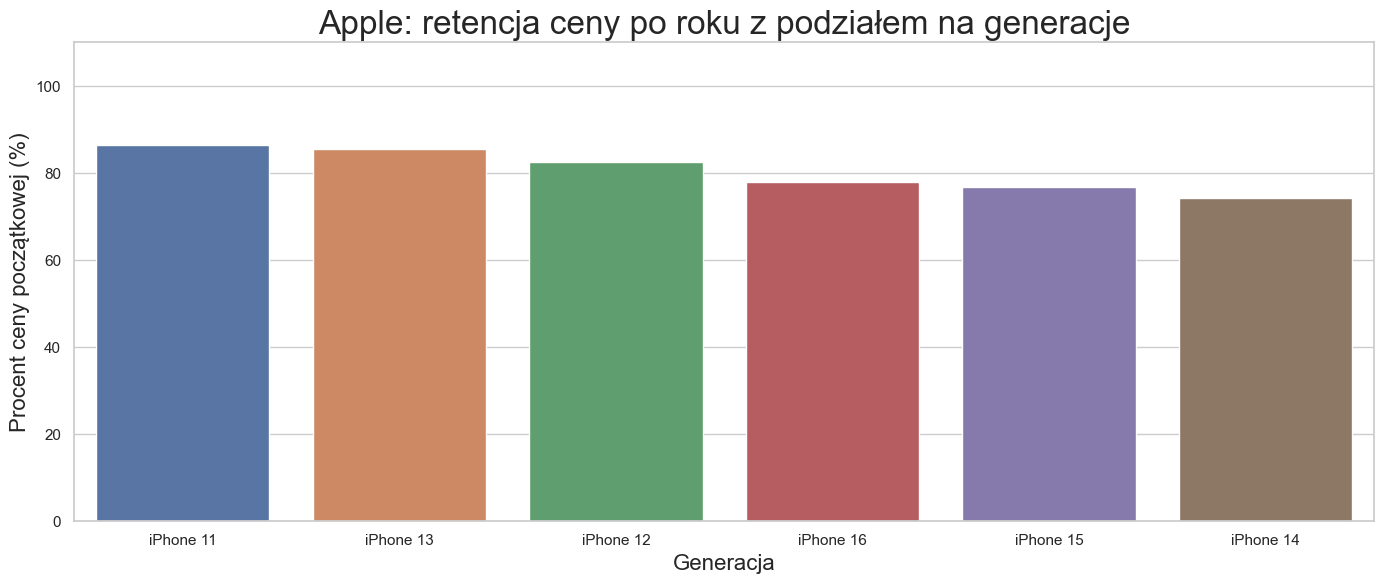

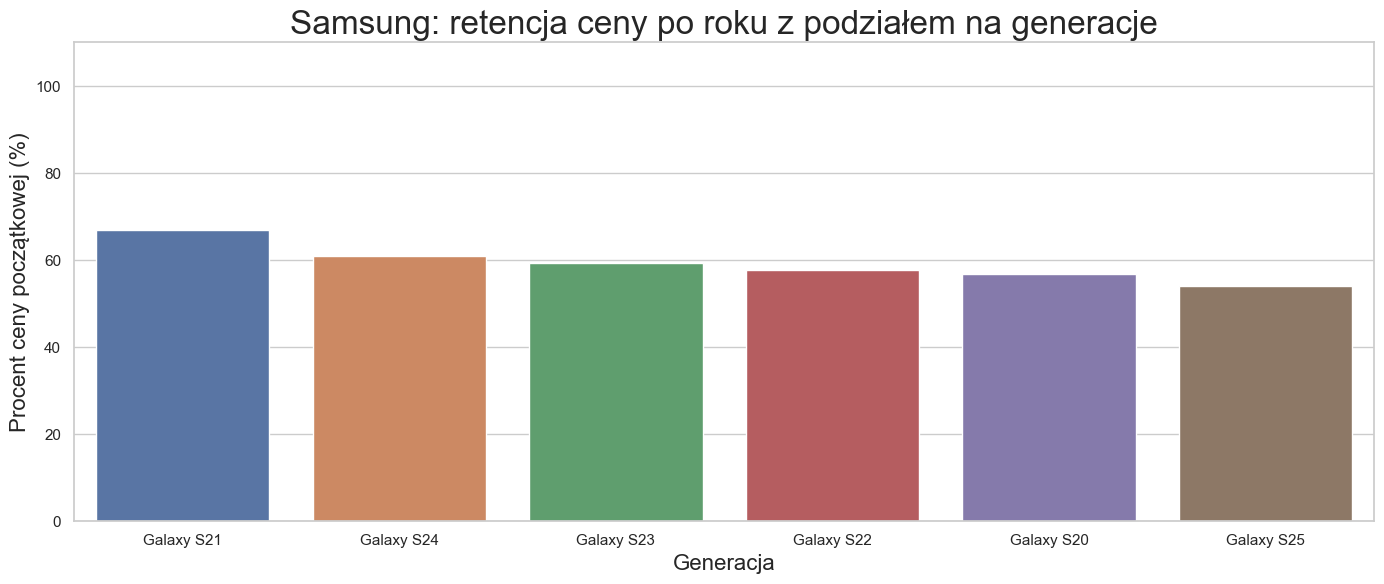

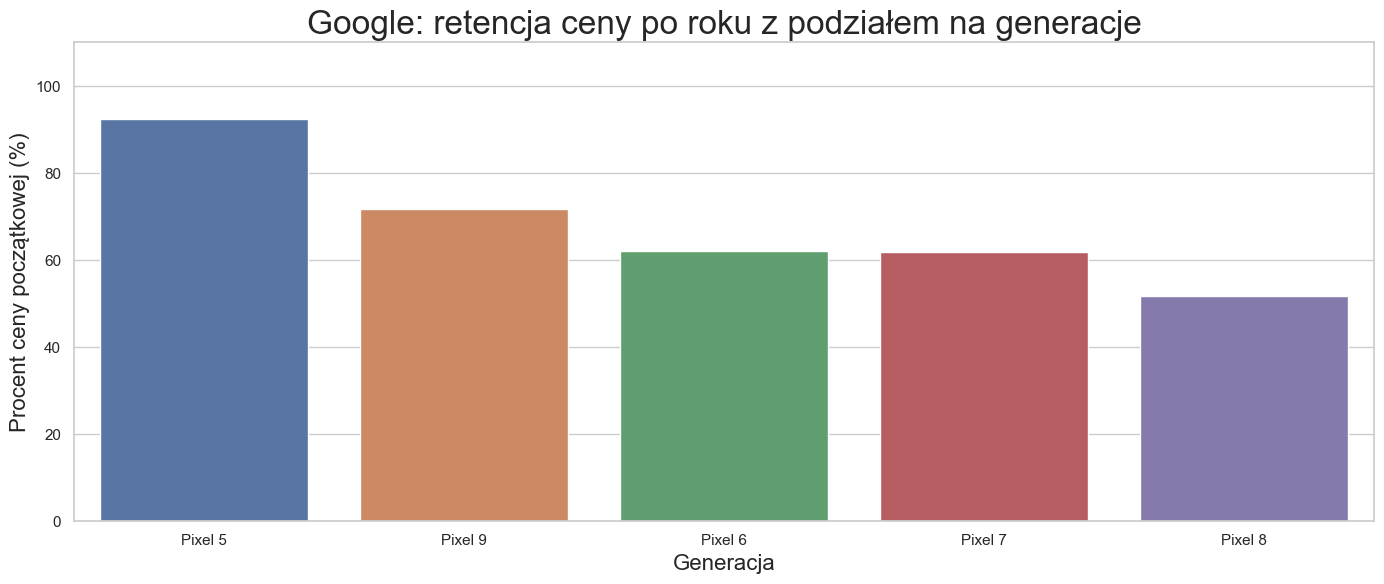

In [21]:
retention_1yr_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = retention_1yr_df.groupby(['generation_name', 'brand']).agg(
    price_retention=('price_pct_of_launch', 'mean')
).reset_index()

for brand in ['Apple', 'Samsung', 'Google']:
    brand_df = retention_1yr_df[retention_1yr_df['brand'] == brand].sort_values('price_retention', ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(
        data=brand_df,
        x='generation_name',
        y='price_retention',
        hue = 'generation_name',
        ax=ax
        )
    ax.set_title(f'{brand}: retencja ceny po roku z podziałem na generacje', fontsize = 24)
    ax.set_xlabel('Generacja', fontsize = 16)
    ax.set_ylabel('Procent ceny początkowej (%)', fontsize = 16)
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.show()

Generacje Apple skupiają się blisko 80% rok po premierze, co świadczy o dość spójnej retencji w całej linii.

Samsung pokazuje podobny rozrzut w okolicach 55-60%. 
 
Pixel 5 to wyraźna anomalia wśród telefonów Google, utrzymując wartość na poziomie zbliżonym do iPhone'ów. Pozostałe Pixele oscylują w okolicach 50-60%.

Pixel 5 zadebiutował w stosunkowo niskiej cenie i Google wycofał go wcześniej niż planowano, co ograniczyło podaż i być może dlatego cena na rynku wtórnym utrzymała się wyżej.

---
## W obrębie generacji: submodele iPhone'a 13

Do tej pory patrzyłem tylko na modele bazowe. Czas zejść poziom niżej i porównać tiery Base i Pro Max w obrębie jednej generacji.

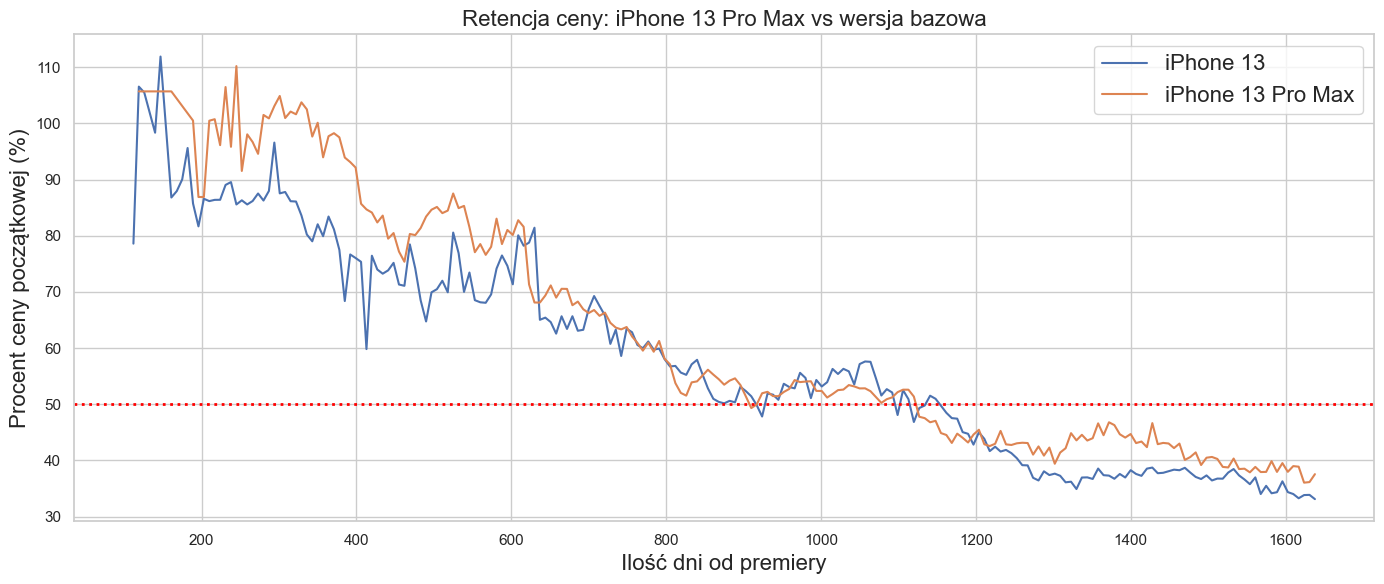

In [22]:
iphone13_decay_df = df[(df['generation_name'] == 'iPhone 13') & (df['tier'].isin(['Base', 'Pro Max']))].groupby(
    ['submodel_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Retencja ceny: iPhone 13 Pro Max vs wersja bazowa', fontsize = 16)
ax.set_xlabel('Ilość dni od premiery', fontsize = 16)
ax.set_ylabel('Procent ceny początkowej (%)', fontsize = 16)
plt.legend(loc = 'upper right', fontsize = 16)
plt.tight_layout()
plt.show()

Pro Max przez większość historii ceny utrzymuje wartość nieco lepiej od modelu bazowego. 

Zachowuje około 40% ceny premierowej nawet po 1600 dniach. 

Zdarzają się momenty, gdy model bazowy wypada lepiej, ale ogólnie Pro Max nieco lepiej zachowuje cenę w tej generacji.

---
## Spadek wartości według tierów

Teraz porównuję wszystkie tiery we wszystkich generacjach dla każdej marki.

To pozwoli sprawdzić, czy droższe warianty faktycznie utrzymują wartość lepiej czy gorzej od bazowych bez względu na generację.

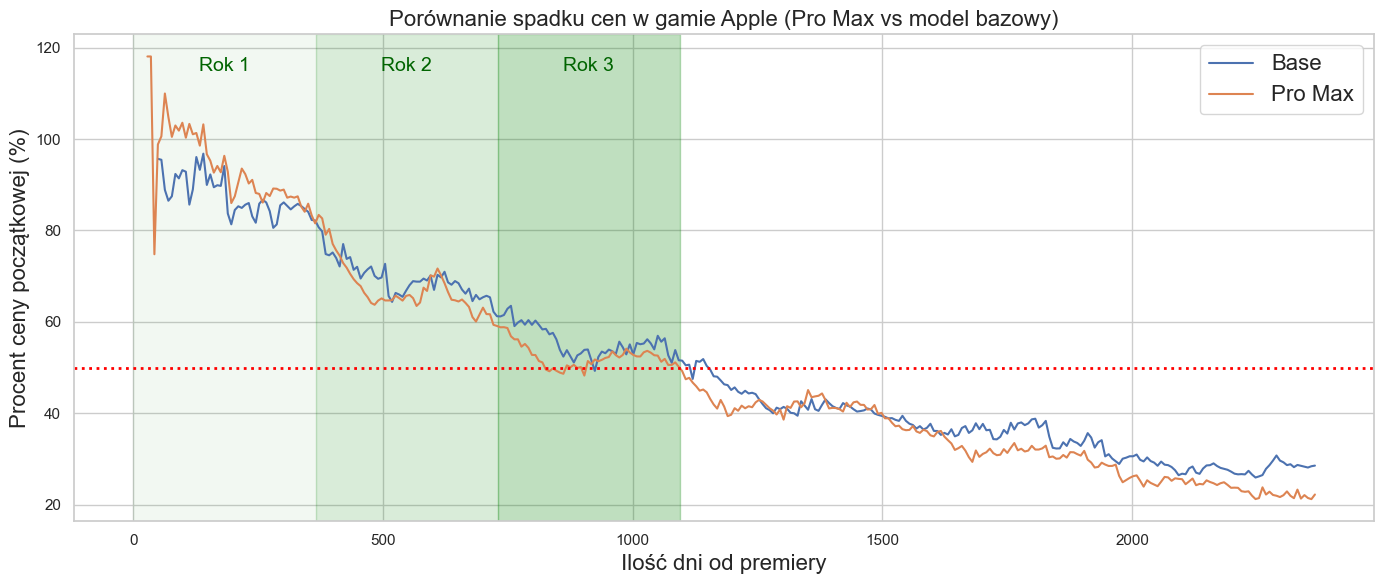

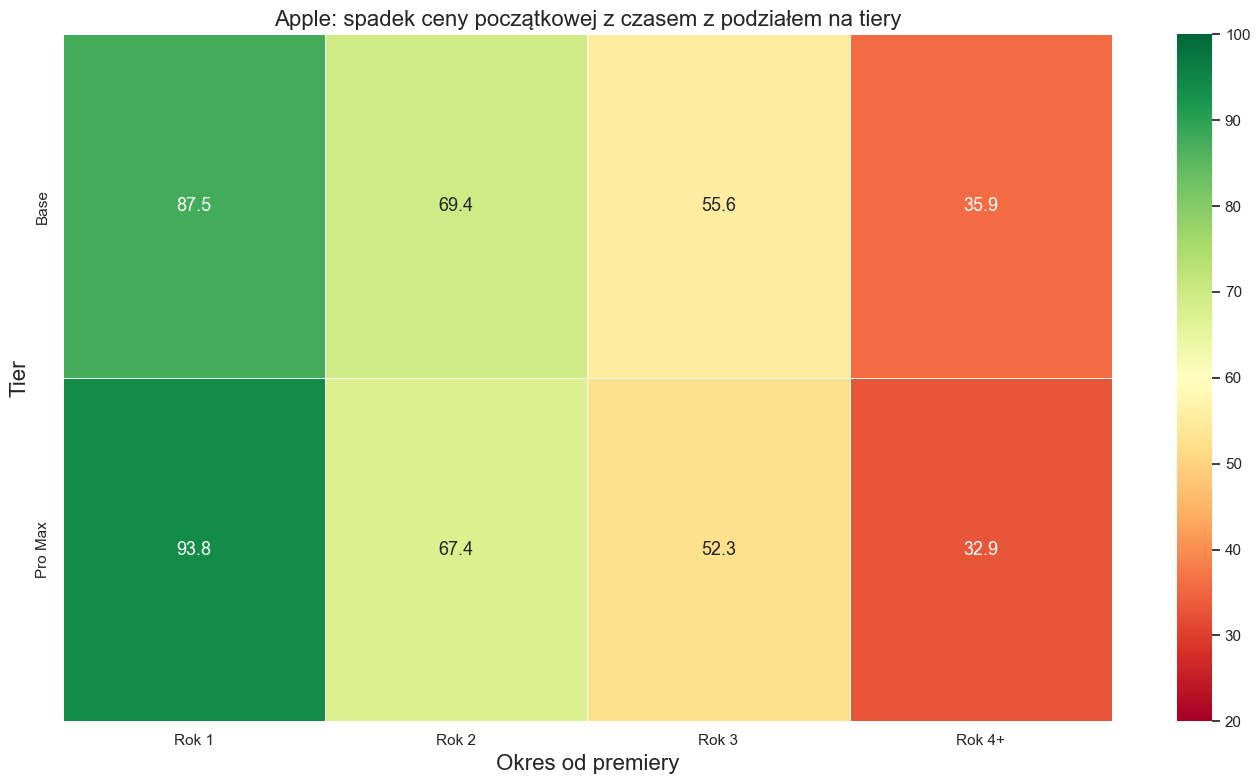

In [23]:

all_brands_tier_df = df.groupby(['brand', 'tier', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
apple_tier_df = all_brands_tier_df[(all_brands_tier_df['brand'] == 'Apple') 
                                   & (all_brands_tier_df['tier'].isin(['Base', 'Pro Max']))]

years = ['Rok 1', 'Rok 2', 'Rok 3', 'Rok 4+']

plt.subplots(figsize=(14, 6))
sns.lineplot(apple_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.legend(loc='upper right', fontsize = 16)
plt.title('Porównanie spadku cen w gamie Apple (Pro Max vs model bazowy)', fontsize = 16)
plt.xlabel('Ilość dni od premiery', fontsize = 16)
plt.ylabel('Procent ceny początkowej (%)', fontsize = 16)
plt.tight_layout()

plt.axhline(50, color='red', linestyle='dotted', linewidth=2)

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 115, years[0], fontsize=14, color='darkgreen', ha='center')
plt.text(547, 115, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 115, years[2], fontsize=14, color='darkgreen', ha='center')
plt.show()


apple_tier_df['year'] = pd.cut(apple_tier_df['days_rounded'],
    bins=[0, 365, 730, 1095, 9999], labels=[years[0], years[1], years[2], years[3]])
apple_heat_df = apple_tier_df.groupby(['tier', 'year'], observed=True)['price_pct_of_launch'].mean().round(1).unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(apple_heat_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=20, vmax=100,
    linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Apple: spadek ceny początkowej z czasem z podziałem na tiery', fontsize = 16)
ax.set_xlabel('Okres od premiery', fontsize = 16)
ax.set_ylabel('Tier', fontsize = 16)
plt.tight_layout()
plt.show()


Wbrew temu, czego można by się spodziewać na podstawie wykresu iPhone'a 13, przy porównaniu wszystkich generacji wychodzi na to, że to model bazowy w dłuższej perspektywie wykazuje najwyższą stabilność cenową.

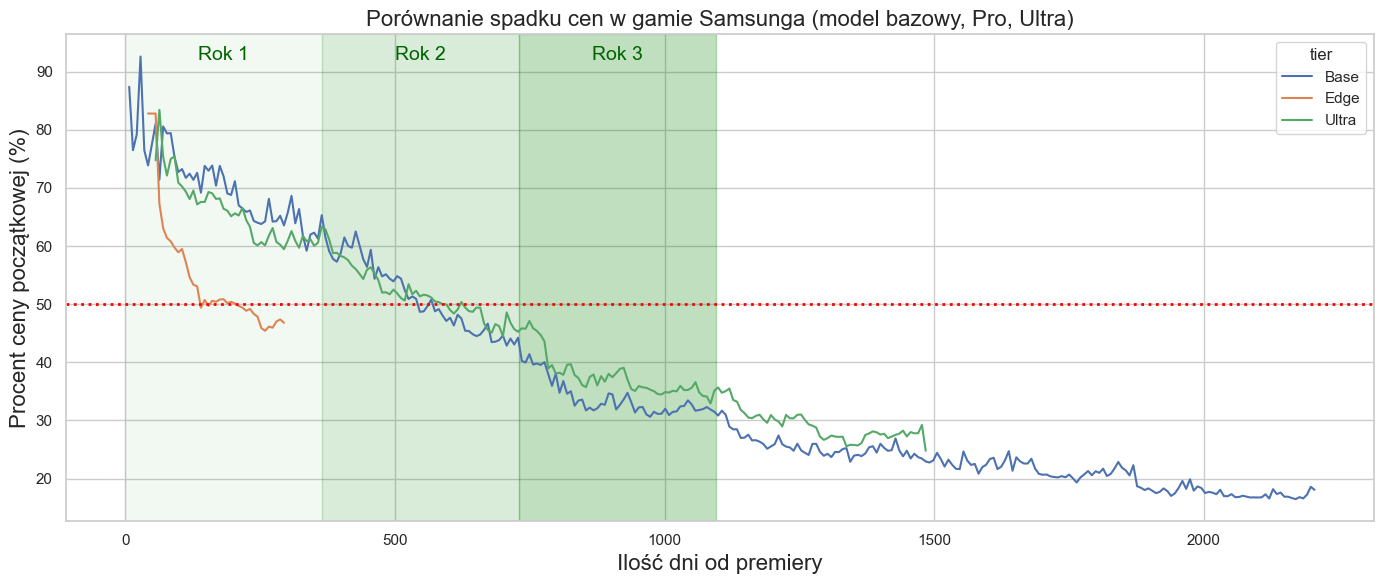

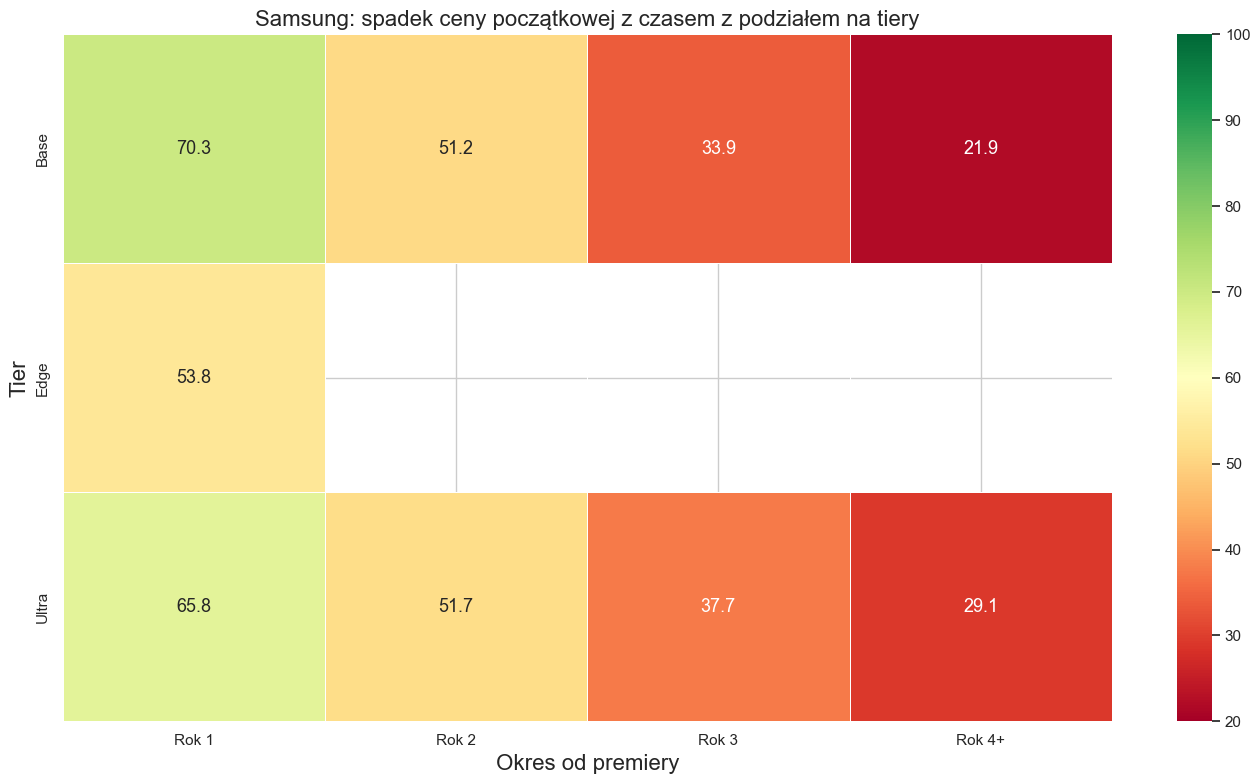

In [24]:

samsung_tier_df = all_brands_tier_df[(all_brands_tier_df['brand'] == 'Samsung') 
                                     & (all_brands_tier_df['tier'].isin(['Base', 'Ultra', 'Edge']))]


plt.subplots(figsize=(14, 6))
sns.lineplot(samsung_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.title('Porównanie spadku cen w gamie Samsunga (model bazowy, Pro, Ultra)', fontsize = 16)
plt.xlabel('Ilość dni od premiery', fontsize = 16)
plt.ylabel('Procent ceny początkowej (%)', fontsize = 16)
plt.tight_layout()

plt.axhline(50, color='red', linestyle='dotted', linewidth=2)

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 92, years[0], fontsize=14, color='darkgreen', ha='center')
plt.text(547, 92, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 92, years[2], fontsize=14, color='darkgreen', ha='center')
plt.show()

samsung_tier_df['year'] = pd.cut(samsung_tier_df['days_rounded'],
    bins=[0, 365, 730, 1095, 9999], labels=[years[0], years[1], years[2], years[3]])
samsung_heat_df = samsung_tier_df.groupby(['tier', 'year'], observed=True)['price_pct_of_launch'].mean().round(1).unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(samsung_heat_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=20, vmax=100,
    linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Samsung: spadek ceny początkowej z czasem z podziałem na tiery', fontsize = 16)
ax.set_xlabel('Okres od premiery', fontsize = 16)
ax.set_ylabel('Tier', fontsize = 16)
plt.tight_layout()
plt.show()




Samsung przechodzi przez wyraźne fazy:
1. Model bazowy prowadzi w pierwszym roku. 
2. Około 500. dnia Ultra przejmuje prowadzenie i utrzymuje je do końca dostępnych danych.

Model Edge wyróżnia się wyjątkowo gwałtownym spadkiem, prawdopodobnie przez wysokie koszty napraw i obawy o trwałość ekranu wśród kupujących na rynku wtórnym, a także przez utratę znaczenia w momencie, gdy Samsung skupił się na serii Ultra.

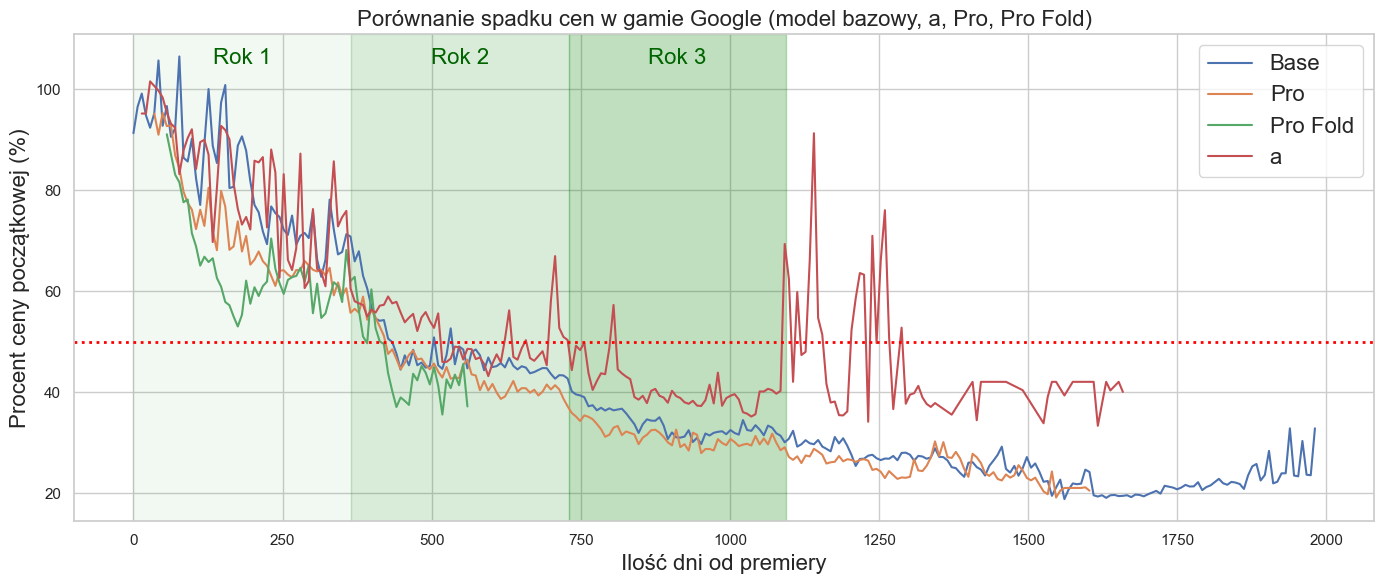

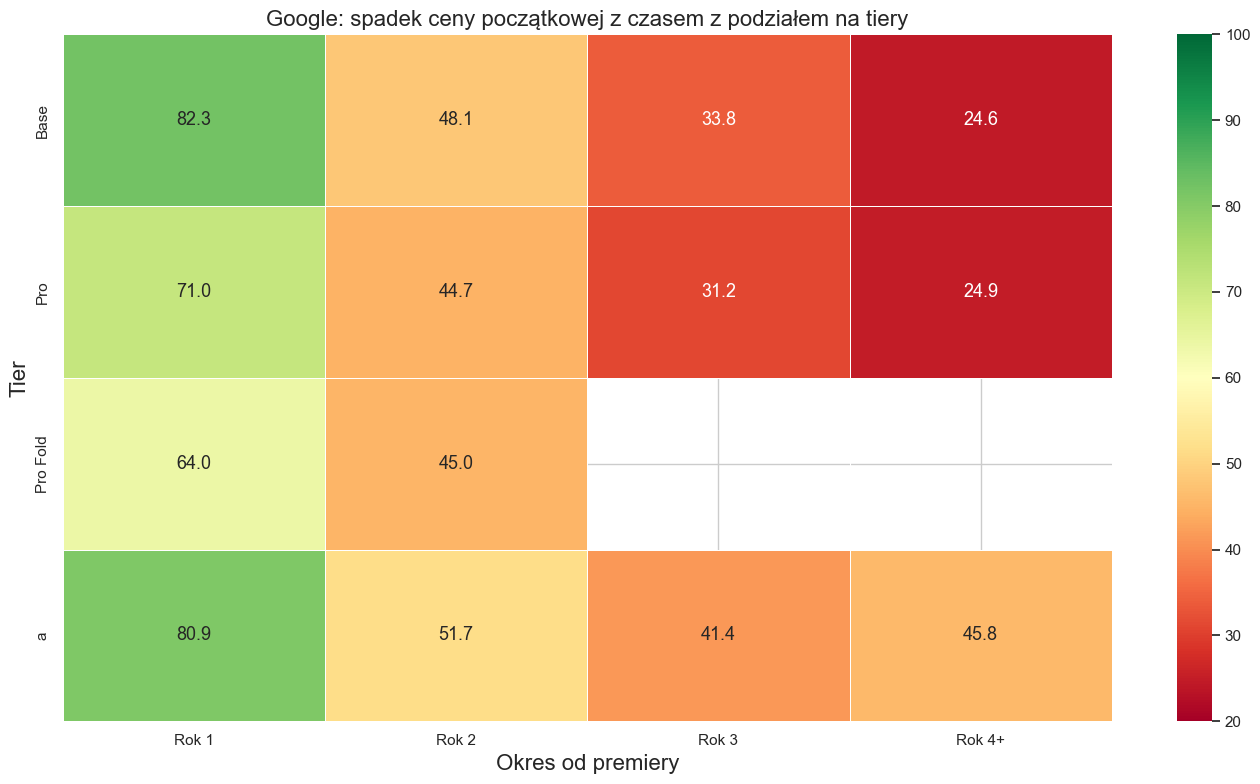

In [25]:
google_tier_df = all_brands_tier_df[(all_brands_tier_df['brand'] == 'Google')
                                    & ((all_brands_tier_df['tier'].isin(['Base', 'Pro', 'Pro Fold', 'a'])))]

plt.subplots(figsize=(14, 6))
sns.lineplot(google_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.title('Porównanie spadku cen w gamie Google (model bazowy, a, Pro, Pro Fold)', fontsize = 16)
plt.xlabel('Ilość dni od premiery', fontsize = 16)
plt.ylabel('Procent ceny początkowej (%)', fontsize = 16)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()

plt.axhline(50, color='red', linestyle='dotted', linewidth=2)

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, years[0], fontsize=16, color='darkgreen', ha='center')
plt.text(547, 105, years[1], fontsize=16, color='darkgreen', ha='center')
plt.text(912, 105, years[2], fontsize=16, color='darkgreen', ha='center')

plt.show()


google_tier_df['year'] = pd.cut(google_tier_df['days_rounded'],
    bins=[0, 365, 730, 1095, 9999], labels=[years[0], years[1], years[2], years[3]])
google_heat_df = google_tier_df.groupby(['tier', 'year'], observed=True)['price_pct_of_launch'].mean().round(1).unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(google_heat_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=20, vmax=100,
    linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Google: spadek ceny początkowej z czasem z podziałem na tiery', fontsize = 16)
ax.set_xlabel('Okres od premiery', fontsize = 16)
ax.set_ylabel('Tier', fontsize = 16)
plt.tight_layout()
plt.show()




Google pokazuje największą polaryzację między tierami. 

Budżetowa seria 'a' to lider retencji wartości, choć z wyraźnie dużą zmiennością. 

Model Pro Fold wykazuje jedną z najgwałtowniejszych deprecjacji w całym zbiorze.

---
## Spadek cen w dolarach

Procenty to jedno, ale wartości w USD dają bardziej konkretny punkt odniesienia dla osoby potencjalnie zainteresowanej zakupem danego smartfona.

Poniższe wykresy pokazują, ile faktycznie kosztuje dana marka w różnych momentach. Ceny są uśrednione po wszystkich generacjach, rozmiarach pamięci i kolorach.

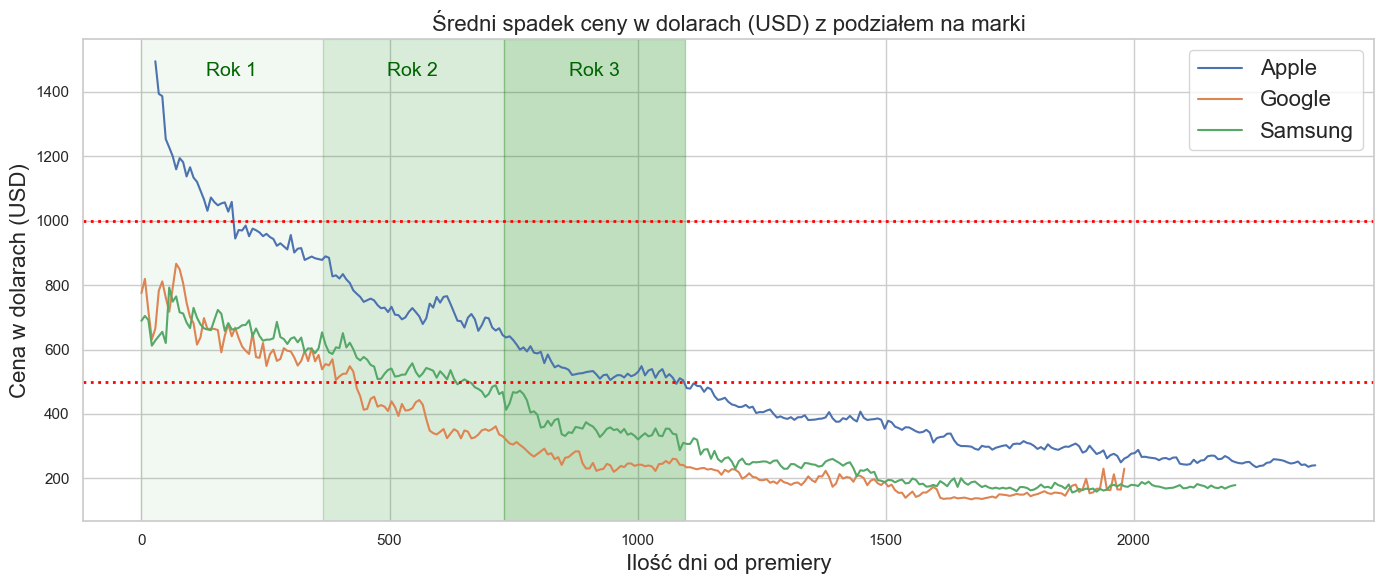

In [26]:
dollar_all_brands_df = df.groupby(['brand', 'days_rounded'])['NEW'].mean().reset_index()


plt.subplots(figsize=(14, 6))
sns.lineplot(data=dollar_all_brands_df, x='days_rounded', y='NEW', hue='brand')
plt.title('Średni spadek ceny w dolarach (USD) z podziałem na marki', fontsize = 16)
plt.xlabel('Ilość dni od premiery', fontsize = 16)
plt.ylabel('Cena w dolarach (USD)', fontsize = 16)
plt.legend(loc='upper right', fontsize = 16)

plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)

plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1450, years[0], fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1450, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1450, years[2], fontsize=14, color='darkgreen', ha='center')

plt.show()

Apple utrzymuje stałą premię cenową rzędu 200-400 USD nad konkurencją przez cały cykl. 
W pewnych momentach iPhone'y są nawet o 100% droższe od konkurencji. 

Średnia cena minimalna iPhone'a stabilizuje się w okolicach 200-300 USD. 

Google i Samsung startują na podobnym poziomie, czyli około 700-800 USD.
Po pierwszym roku Samsung trzyma wartość nieco lepiej, utrzymując stabilną przewagę około 100 USD nad Google przez resztę cyklu.

#### Porównanie tierów w dolarach

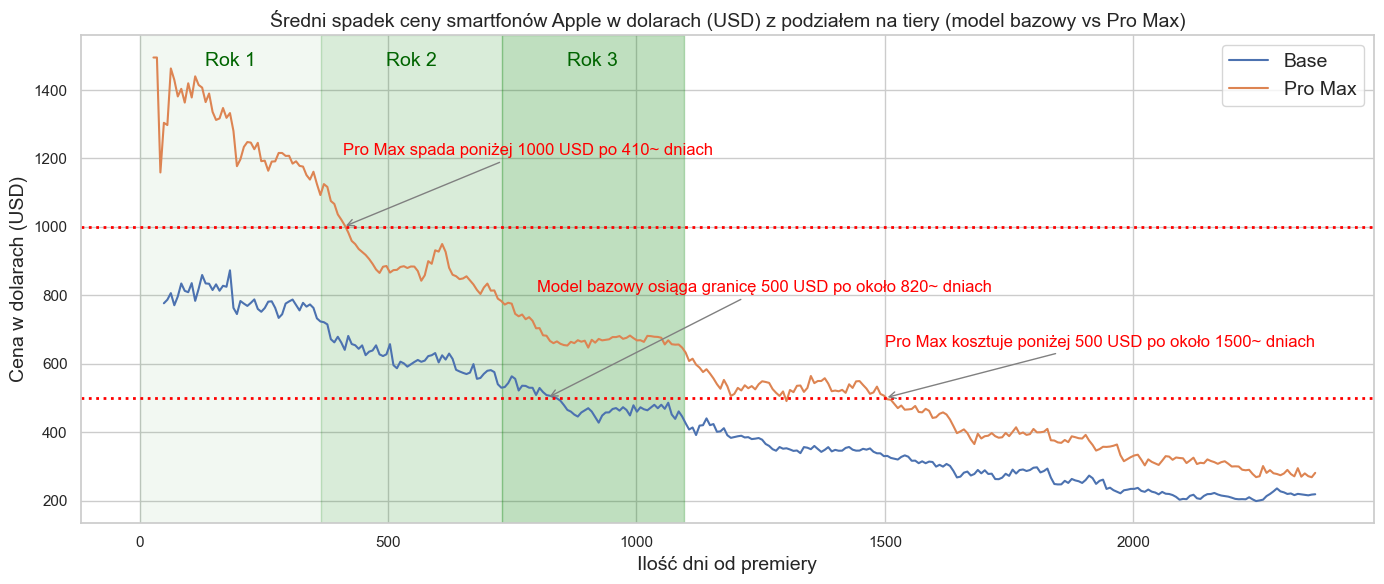

In [27]:
apple_dollar_df = df[(df['brand'] == 'Apple') & (df['tier'].isin(['Base', 'Pro Max']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()


plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.title('Średni spadek ceny smartfonów Apple w dolarach (USD) z podziałem na tiery (model bazowy vs Pro Max)', fontsize=14)
plt.xlabel('Ilość dni od premiery', fontsize=14)
plt.ylabel('Cena w dolarach (USD)', fontsize=14)
plt.legend(loc='upper right', fontsize=14)

plt.axhline(1000, color='red', linestyle='dotted', linewidth=2) #horizontal lines for 500/1000 USD marks
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)


plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')

plt.text(182, 1470, years[0], fontsize=14, color='darkgreen', ha='center') #YEARLY vertical spans for years
plt.text(547, 1470, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1470, years[2], fontsize=14, color='darkgreen', ha='center')

plt.annotate(
    text = 'Pro Max spada poniżej 1000 USD po 410~ dniach',
    xy = (410, 1000),
    xytext= (410, 1210),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Model bazowy osiąga granicę 500 USD po około 820~ dniach',
    xy = (820, 500),
    xytext= (800, 810),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Pro Max kosztuje poniżej 500 USD po około 1500~ dniach',
    xy = (1500, 500),
    xytext= (1500, 650),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.savefig('wykres2.png', dpi=300, bbox_inches='tight')
plt.show()



Na premierze Pro Max jest droższy od modelu bazowego o ponad 600 USD (około 75%). Ta różnica szybko się kurczy: w pierwszym roku Pro Max traci średnio około 30% ceny, schodząc poniżej 1000 USD niedługo po tym, podczas gdy model bazowy traci tylko około 10% ceny.

Redukuje to pierwotną premię Pro Maxa mniej więcej o połowę, do poziomu około 400 USD. 
Ta różnica kurczy się do 250-300 USD i utrzymuje się dość stabilnie przez kolejne dwa lata. 

Po 2000 dniach Pro Max stabilizuje się blisko 280 USD, a model bazowy blisko 200 USD.

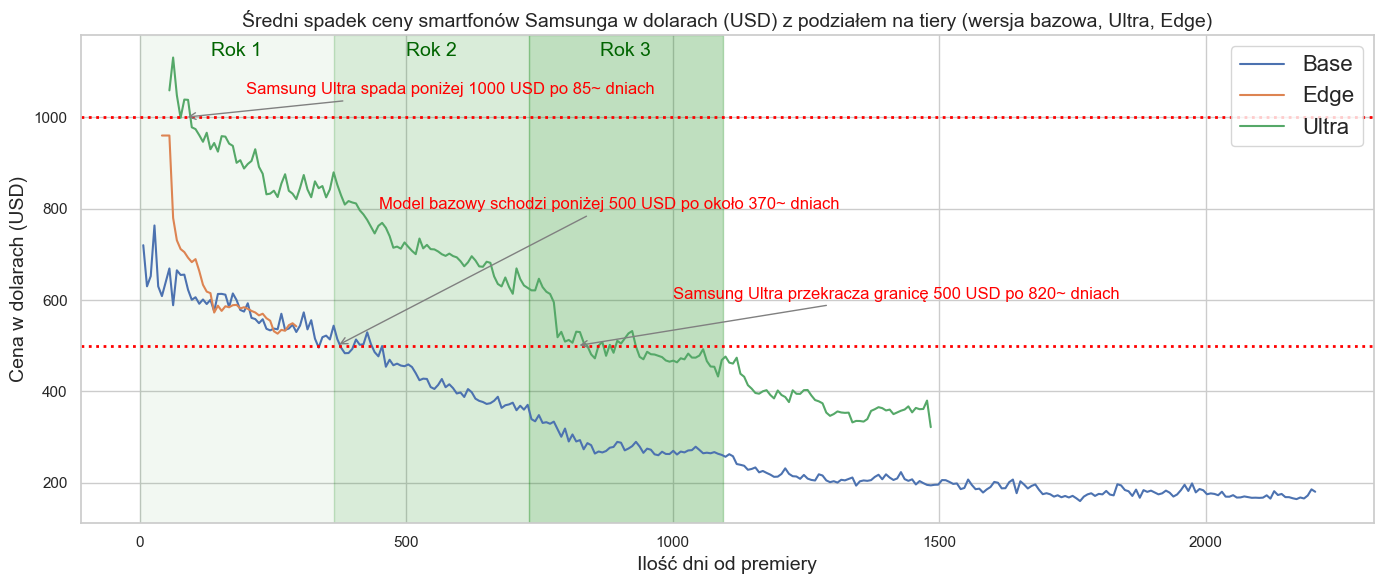

In [28]:

samsung_dollar_df = df[(df['brand'] == 'Samsung') & (df['tier'].isin(['Base', 'Ultra', 'Edge']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()


plt.subplots(figsize=(14, 6))
sns.lineplot(data=samsung_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.title('Średni spadek ceny smartfonów Samsunga w dolarach (USD) z podziałem na tiery (wersja bazowa, Ultra, Edge)', fontsize=14)
plt.xlabel('Ilość dni od premiery', fontsize=14)
plt.ylabel('Cena w dolarach (USD)', fontsize=14)

plt.axhline(1000, color='red', linestyle='dotted', linewidth=2) #horizontal lines for 1000 USD and 500 USD mark
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)

plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green') #YEARLY vertical spans for years
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1135, years[0], fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1135, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1135, years[2], fontsize=14, color='darkgreen', ha='center')

plt.annotate(
    text = 'Samsung Ultra spada poniżej 1000 USD po 85~ dniach',
    xy = (85, 1000),
    xytext= (200, 1050),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Samsung Ultra przekracza granicę 500 USD po 820~ dniach',
    xy = (820, 500),
    xytext= (1000, 603),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Model bazowy schodzi poniżej 500 USD po około 370~ dniach',
    xy = (370, 500),
    xytext= (450, 800),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )


plt.savefig('wykres9.png', dpi=300, bbox_inches='tight')
plt.show()

Edge startuje w okolicach 950 USD i gwałtownie traci wartość, zrównując się z modelem bazowym już po upływie około 150-180 dni. 

Ultra zaczyna z ceną około 1150 USD i spada poniżej 1000 USD w ciągu kilku miesięcy, stabilizując się na poziomie 850-900 USD po pierwszym roku. Premia cenowa nad modelem bazowym zanika powoli i utrzymuje się na dość stabilnym poziomie 200-300 USD aż do końca dostępnych danych.

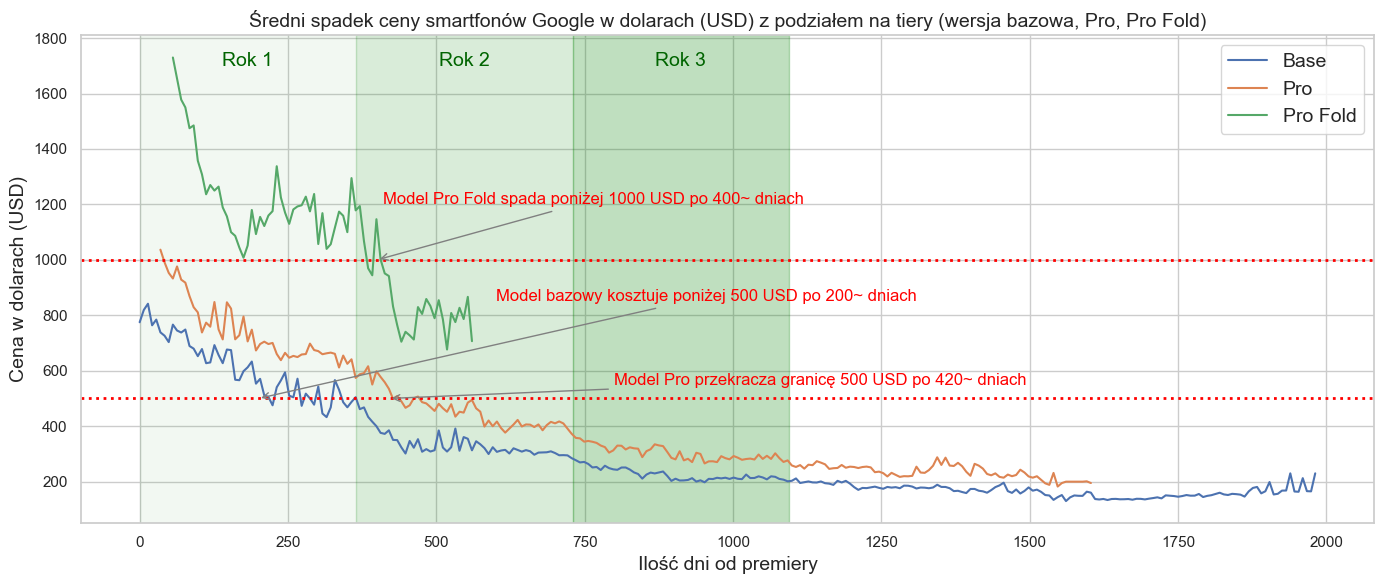

In [29]:
google_dollar_df = df[(df['brand'] == 'Google') & (df['tier'].isin(['Base', 'Pro', 'Pro Fold']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()


plt.subplots(figsize=(14, 6))
sns.lineplot(data=google_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.title('Średni spadek ceny smartfonów Google w dolarach (USD) z podziałem na tiery (wersja bazowa, Pro, Pro Fold)', fontsize=14)
plt.xlabel('Ilość dni od premiery', fontsize=14)
plt.ylabel('Cena w dolarach (USD)', fontsize=14)

plt.axhline(1000, color='red', linestyle='dotted', linewidth=2) #horizontal lines for 500/1000 USD marks
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)

plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green') #YEARLY vertical spans for years
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, years[0], fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, years[1], fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, years[2], fontsize=14, color='darkgreen', ha='center')

#annotations
plt.annotate(
    text = 'Model Pro Fold spada poniżej 1000 USD po 400~ dniach',
    xy = (400, 1000),
    xytext= (410, 1200),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Model Pro przekracza granicę 500 USD po 420~ dniach',
    xy = (420, 500),
    xytext= (800, 550),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )

plt.annotate(
    text = 'Model bazowy kosztuje poniżej 500 USD po 200~ dniach',
    xy = (200, 500),
    xytext= (600, 850),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, color='red'
    )


plt.savefig('wykres8.png', dpi=300, bbox_inches='tight')
plt.show()

Pro Fold startuje przy 1700 USD i traci ponad 50% wartości w ciągu 500 dni, co czyni go najszybciej tracącym wartość modelem w całym zbiorze.

Modele Base i Pro tracą wartość wyjątkowo podobnie, zaczynając z różnicą zaledwie 200-250 USD, która zawęża się do poniżej 100 USD już po pierwszym roku.

---
## Rozkład cen przez cały cykl

Boxplot poniżej pokazuje pełny rozkład średnich cen przez cały cykl dla każdej marki: medianę, kwartyle i outliery. Daje to obraz zmienności cen w obrębie każdej marki.

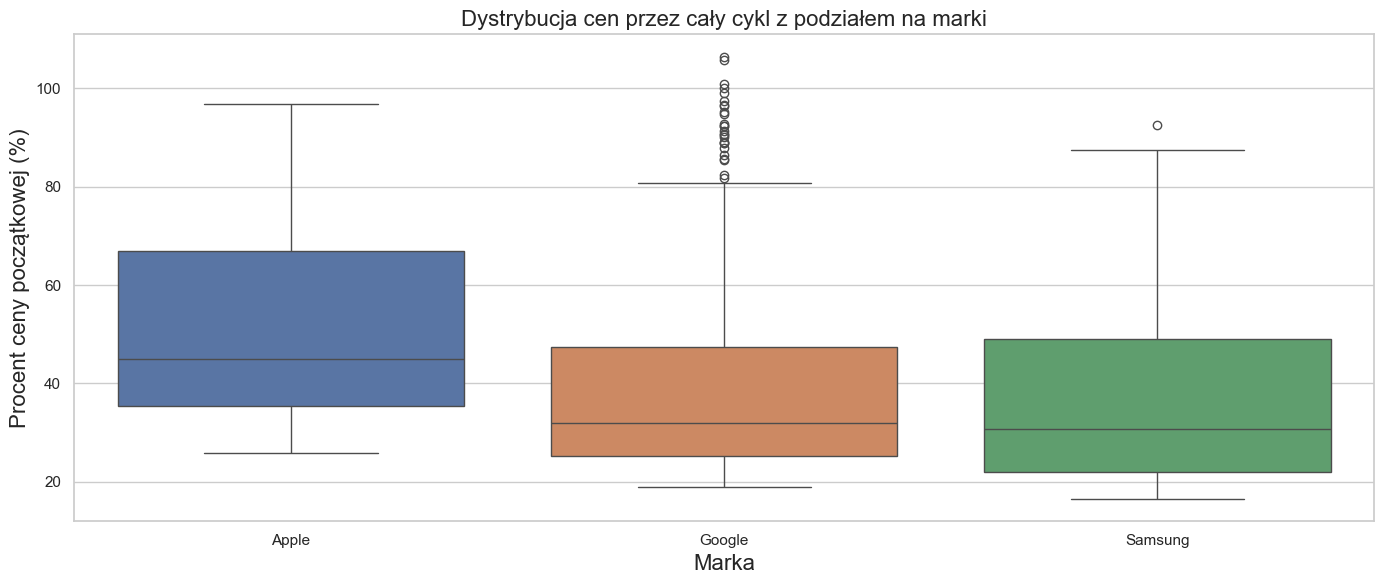

In [30]:
base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

plt.subplots(figsize = (14, 6))
sns.boxplot(data=all_brands_decay_df, x='brand', y='price_pct_of_launch', hue='brand')
plt.title('Dystrybucja cen przez cały cykl z podziałem na marki', fontsize = 16)
plt.xlabel('Marka', fontsize = 16)
plt.ylabel('Procent ceny początkowej (%)', fontsize = 16)
plt.tight_layout()
plt.show()

Apple wyraźnie prowadzi pod względem mediany, a IQR jest przesunięty wyżej niż u konkurencji. 

Google i Samsung mają podobne do siebie rozkłady, ale marka Google ma też najwyższą liczbę outlierów spośród trzech marek.

---
## Pipeline danych sprzedażowych

Po analizie spadku cen chcę przyjrzeć się również danym sprzedażowym.

### Krok 1: Czyszczenie i przygotowanie

Łączę dane sprzedażowe z tabelą referencyjną (original_launch_ref), żeby uzyskać daty premier i wyciągam nazwy tierów, stosując tę samą logikę co przy danych cenowym.

In [31]:
ms_df = ms_df.merge(original_launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]


ms_df['tier'] = [
    submodel.replace(generation, '').strip()
    for submodel, generation in zip(ms_df['submodel_name'], ms_df['generation_name'])
]
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

print(f"Sales rows after cleaning: {ms_df.shape[0]:,}")
ms_df[['asin', 'submodel_name', 'tier', 'datetime', 'monthly_sold']].head(8)

Sales rows after cleaning: 17,938


,asin,submodel_name,tier,datetime,monthly_sold
0,B011SDYBZW,iPhone 11,Base,2023-10-20 07:04:00,50
1,B011SDYBZW,iPhone 11,Base,2023-11-28 13:34:00,100
2,B011SDYBZW,iPhone 11,Base,2024-01-01 08:42:00,50
3,B011SDYBZW,iPhone 11,Base,2024-01-01 18:16:00,100
4,B011SDYBZW,iPhone 11,Base,2024-01-02 14:56:00,50
5,B07ZPJ58KN,iPhone 11,Base,2023-10-20 00:52:00,100
6,B07ZPJ58KN,iPhone 11,Base,2023-11-26 05:26:00,200
7,B07ZPJ58KN,iPhone 11,Base,2023-12-06 10:06:00,100


### Krok 2: Resample i agregacja

Ponieważ `monthly_sold` jest aktualizowany kilka razy w ciągu miesiąca, pobieram ostatni odczyt każdego miesiąca dla każdego ASIN-u za pomocą metody `resample('ME').last()`. Pozwala to uniknąć wielokrotnego liczenia pośrednich aktualizacji.

Następnie sumuję wyniki po ASIN-ach zamiast uśredniać. Uśrednianie niedoszacowałoby aktywności modeli z większą liczbą wariantów (np. iPhone 16 Pro ma 23 ASIN-y, Galaxy S22 ma 8). Sumowanie daje dolną granicę zakresu, którą będzie można porównać między modelami.

Keepa śledzi te dane dopiero od końca 2023 roku, więc mamy dane z około 2.5 roku (pobierałem dane w lutym 2026).

In [32]:
new_ms_df = ms_df.copy().set_index(ms_df['datetime'])
new_ms_df = new_ms_df.groupby('asin').resample('ME').last()
new_ms_df = new_ms_df[(new_ms_df['submodel_name'].notna()) & (new_ms_df['monthly_sold'] >= 0)]
new_ms_df['month_year'] = new_ms_df['datetime'].dt.to_period('M').dt.to_timestamp()

print(f"Months covered: {new_ms_df['month_year'].nunique()}")
print(f"ASINs tracked: {new_ms_df.index.get_level_values('asin').nunique()}")

Months covered: 31
ASINs tracked: 362


---
## Miesięczna sprzedaż według marki

Zaczynam od najbardziej ogólnego widoku, który pokazuje łączny wskaźnik sprzedaży każdej marki co miesiąc.

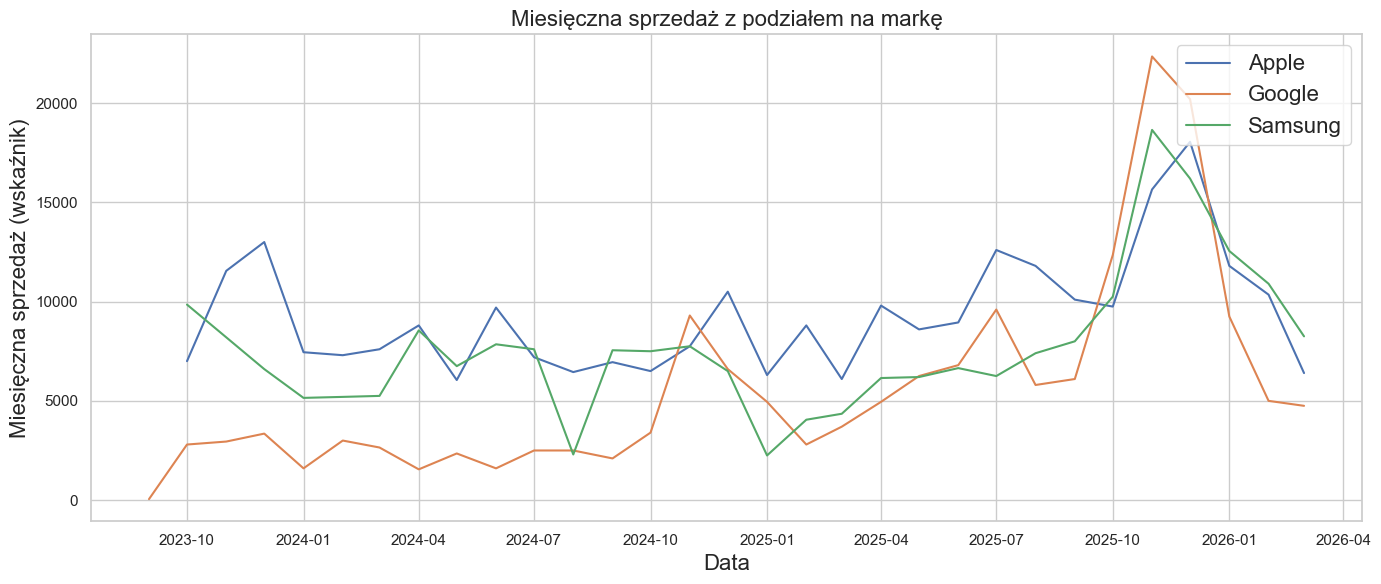

In [33]:
brand_ms_df = new_ms_df.groupby(['brand', 'month_year'])['monthly_sold'].sum().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=brand_ms_df, x='month_year', y='monthly_sold', hue='brand')
plt.title('Miesięczna sprzedaż z podziałem na markę', fontsize=16)
plt.ylabel('Miesięczna sprzedaż (wskaźnik)', fontsize=16)
plt.xlabel('Data', fontsize=16)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

Apple prowadzi, choć różnice nie są duże i marka często szła łeb w łeb z Samsungiem. 

Google zanotował pierwszy większy skok w Q4 2024, potem w lipcu 2025 i Q4 2025. 

Wszystkie trzy marki notują wyraźny wzrost w Q4 2025. Google i Apple rosną też w lipcu 2025, czyli mniej więcej wtedy, gdy na Amazonie odbywa się tzw. Prime Day (coroczny festiwal okazji).

---
## Miesięczna sprzedaż według tierów

Rozkład na tiery w każdej marce pozwala zobaczyć, które tiery napędzają popyt na rynku wtórnym.

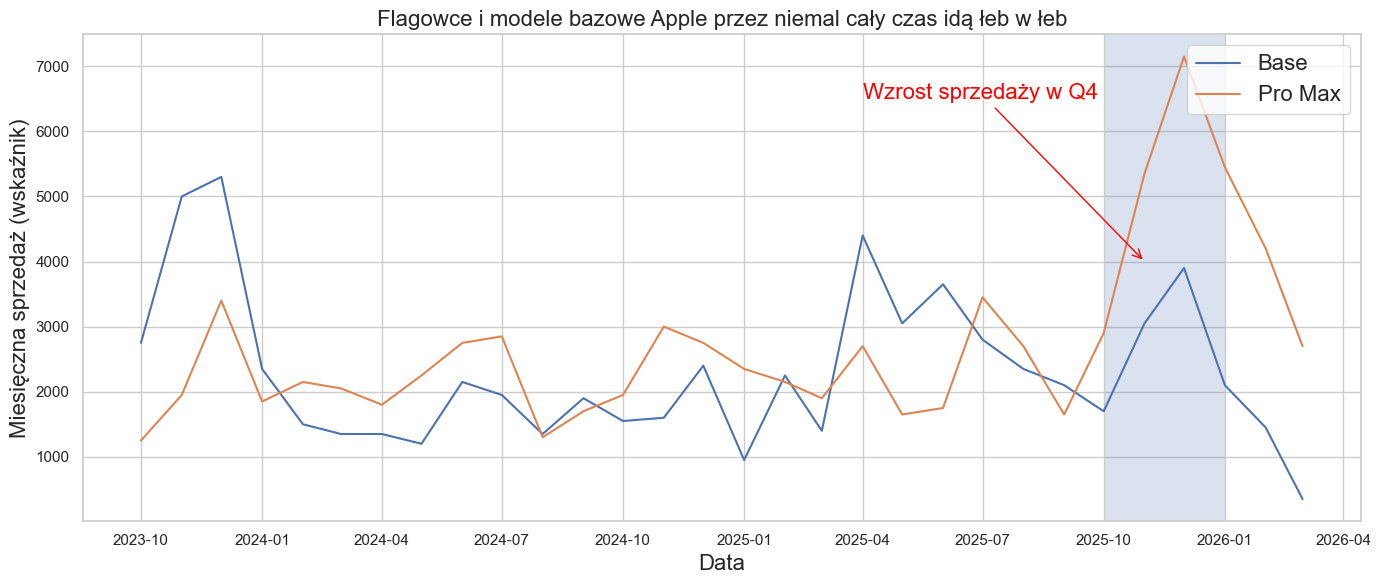

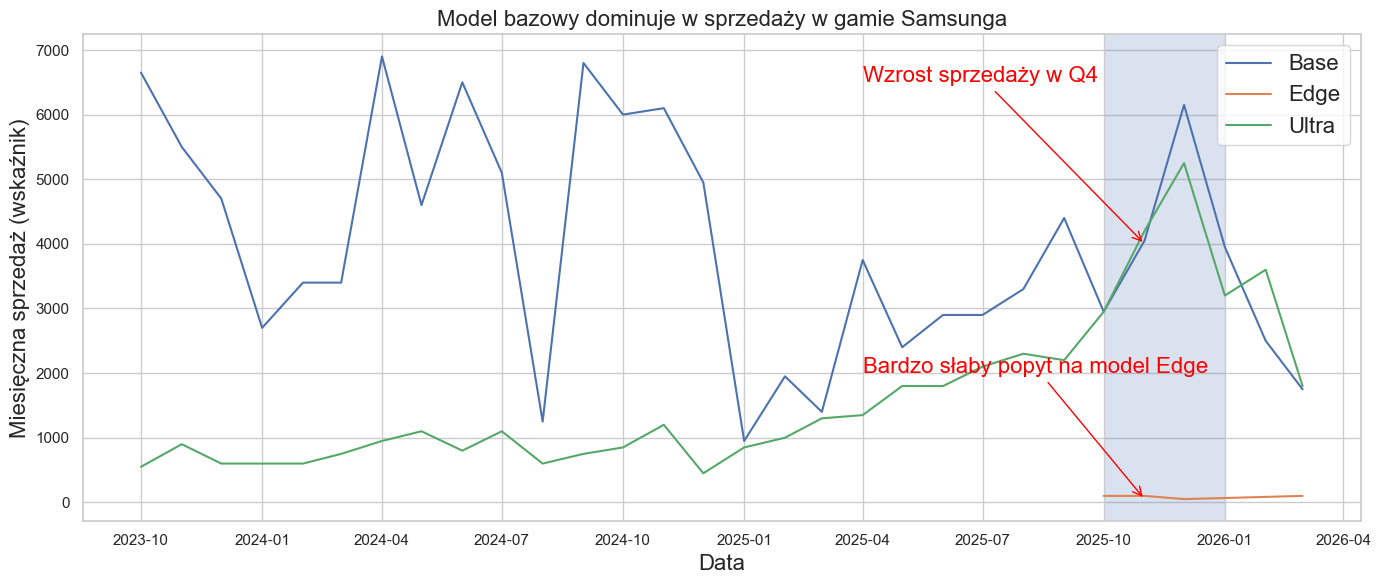

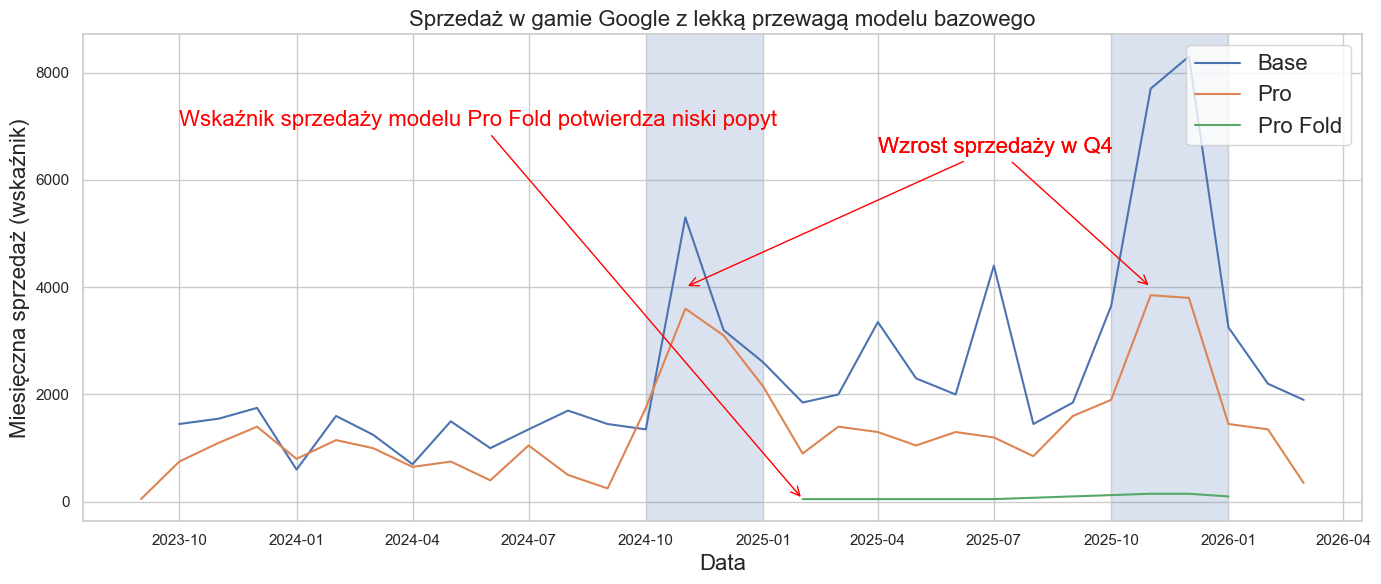

In [34]:
brand_tier_ms_df = new_ms_df.groupby(['brand', 'tier', 'month_year'])['monthly_sold'].sum().reset_index()

apple_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Apple') & (brand_tier_ms_df['tier'].isin(['Base', 'Pro Max']))].copy()
plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Flagowce i modele bazowe Apple przez niemal cały czas idą łeb w łeb', fontsize=16)
plt.ylabel('Miesięczna sprzedaż (wskaźnik)', fontsize=16)
plt.xlabel('Data', fontsize=16)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()

plt.axvspan(
    xmin = '2025-10',
    xmax = '2026-01',
    alpha = 0.2
    )

plt.annotate(
    text='Wzrost sprzedaży w Q4',
    xy=(pd.Timestamp('2025-11-01'), 4000), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2025-04-01'), 6500),
    arrowprops=dict(arrowstyle='->', color='red'),
)


plt.show()

samsung_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Samsung') & (brand_tier_ms_df['tier'].isin(['Base', 'Ultra', 'Edge']))].copy()
plt.subplots(figsize=(14, 6))
sns.lineplot(data=samsung_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Model bazowy dominuje w sprzedaży w gamie Samsunga', fontsize=16)
plt.ylabel('Miesięczna sprzedaż (wskaźnik)', fontsize=16)
plt.xlabel('Data', fontsize=16)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()

plt.axvspan(
    xmin = '2025-10',
    xmax = '2026-01',
    alpha = 0.2
    )

plt.annotate(
    text='Wzrost sprzedaży w Q4',
    xy=(pd.Timestamp('2025-11-01'), 4000), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2025-04-01'), 6500),
    arrowprops=dict(arrowstyle='->', color='red'),
)

plt.annotate(
    text='Bardzo słaby popyt na model Edge',
    xy=(pd.Timestamp('2025-11-01'), 50), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2025-04-01'), 2000),
    arrowprops=dict(arrowstyle='->', color='red'),
)


plt.show()




google_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Google') & (brand_tier_ms_df['tier'].isin(['Base', 'Pro', 'Pro Fold']))].copy()
plt.subplots(figsize=(14, 6))
sns.lineplot(data=google_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Sprzedaż w gamie Google z lekką przewagą modelu bazowego', fontsize=16)
plt.ylabel('Miesięczna sprzedaż (wskaźnik)', fontsize=16)
plt.xlabel('Data', fontsize=16)
plt.legend(loc='upper right', fontsize=16)

plt.axvspan(
    xmin = '2025-10',
    xmax = '2026-01',
    alpha = 0.2
    )
plt.axvspan(
    xmin = '2024-10',
    xmax = '2025-01',
    alpha = 0.2
    )

plt.annotate(
    text='Wzrost sprzedaży w Q4',
    xy=(pd.Timestamp('2025-11-01'), 4000), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2025-04-01'), 6500),
    arrowprops=dict(arrowstyle='->', color='red'),
)

plt.annotate(
    text='Wzrost sprzedaży w Q4',
    xy=(pd.Timestamp('2024-11-01'), 4000), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2025-04-01'), 6500),
    arrowprops=dict(arrowstyle='->', color='red'),
)

plt.annotate(
    text='Wskaźnik sprzedaży modelu Pro Fold potwierdza niski popyt',
    xy=(pd.Timestamp('2025-02-01'), 50), fontsize = 16, color = 'red',
    xytext=(pd.Timestamp('2023-10-01'), 7000),
    arrowprops=dict(arrowstyle='->', color='red'),
)


plt.tight_layout()
plt.show()


#I've also marked all the major sales spikes (mostly Q4) with axvspan

Dostępne okno danych jest dość krótkie, więc obserwacje należy traktować z pewną dozą ostrożności.

Tiery Pro Max i bazowy Apple'a naprzemiennie obejmują prowadzenie, do wyciągnięcia bardziej konkretnych obserwacji potrzebne byłoby dłuższe okno danych.

Model bazowy Samsunga prowadzi przez większość okresu, choć Ultra notuje wyraźny skok w Q4 2025.
Wariant Edge, już wcześniej oznaczony jako słaby pod kątem retencji ceny, potwierdza swoją niską pozycję również w danych sprzedażowych.

Modele Pro i bazowy Google'a idą łeb w łeb, co odpowiada niewielkim różnicom wykazanym przy analizie retencji ceny. 
Model bazowy mocno skacze w Q4 2025. Pro Fold konsekwentnie notuje niski wolumen, potwierdzając swój niszowy charakter i słaby popyt.

---
## Sprzedaż modeli bazowych Apple

Pora spojrzeć na sprzedaż modeli bazowych każdej marki i zobaczyć, czy widać wyraźne sezonowe wzorce i czy premiery nowych modeli mają jakiś wpływ na zachowanie starszych.

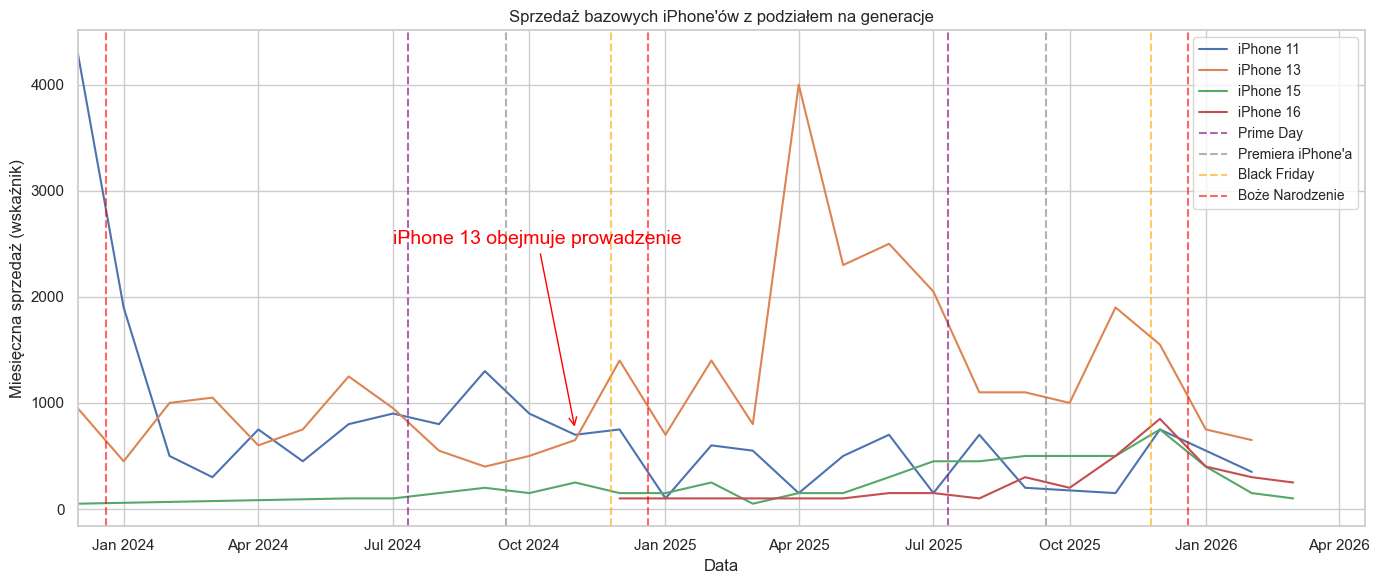

In [35]:
submodel_ms_df = new_ms_df.groupby(['brand', 'submodel_name', 'tier', 'generation_name', 'month_year'])['monthly_sold'].sum().reset_index()
apple_base_ms_df = submodel_ms_df[(submodel_ms_df['brand'] == 'Apple') & (submodel_ms_df['tier'] == 'Base')].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_base_ms_df, x='month_year', y='monthly_sold', hue='generation_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Premiera iPhone\'a')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Boże Narodzenie')

for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sprzedaż bazowych iPhone\'ów z podziałem na generacje')
ax.set_xlabel('Data')
ax.set_ylabel('Miesięczna sprzedaż (wskaźnik)')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))

plt.annotate(
    text='iPhone 13 obejmuje prowadzenie', fontsize = 14, color = 'red',
    xy=(pd.Timestamp('2024-11-01'), 750),
    xytext=(pd.Timestamp('2024-07-01'), 2500),
    arrowprops=dict(arrowstyle='->', color='red'),
)


plt.tight_layout()
plt.show()

## iPhone 13: król rynku wtórnego
- iPhone 11 i 13 idą łeb w łeb przez cały 2024 rok. W 2025 sprzedaż iPhone'a 11 wyraźnie spada, a iPhone 13 wyraźnie pikuje, stając się niekwestionowanym liderem sprzedaży na rynku używanych iPhone'ów.

## Inne obserwacje

- Widać oznaki wzrostu sprzedaży iPhone'a 15 przed premierą iPhone'a 17, tuż przed Prime Day, choć nie jest to duży skok.
- Wzrost sprzedaży iPhone'a 16 bezpośrednio przed premierą iPhone'a 17 może być też efektem ogólnego wzrostu w Q4.

Dominacja iPhone'a 13 i skoki sprzedaży w Q4 są relatywnie wyraźnymi sygnałami, ale nawet je warto traktować z rezerwą, bo do potwierdzenia trendów potrzeba więcej danych.

---
## Sprzedaż submodeli iPhone'ów 11, 13 i 15

Mając obraz na poziomie generacji, czas zejść poziom niżej i sprawdzić, czy są jakieś różnice w sprzedaży poszczególnych tierów w różnych generacjach.

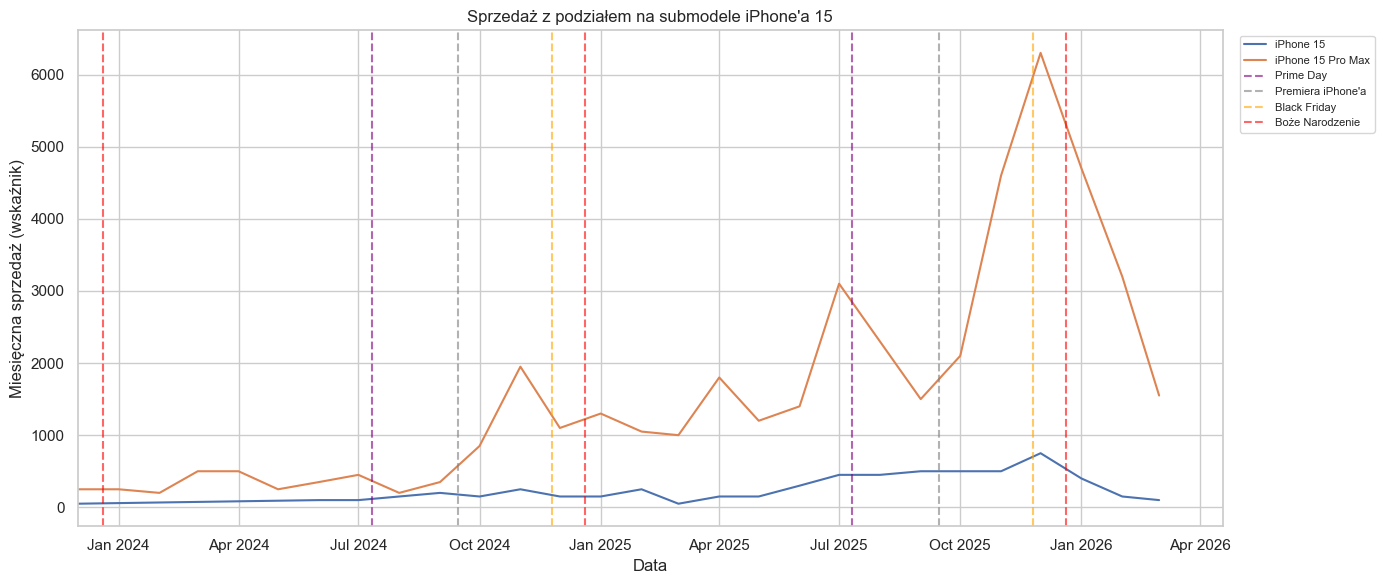

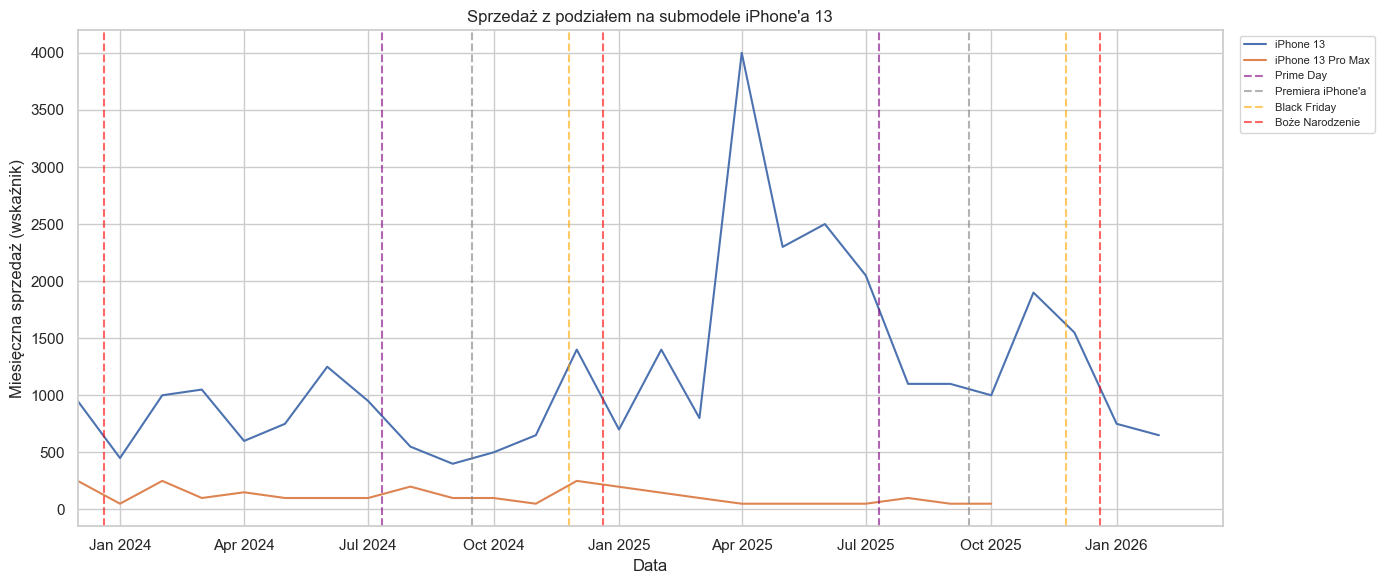

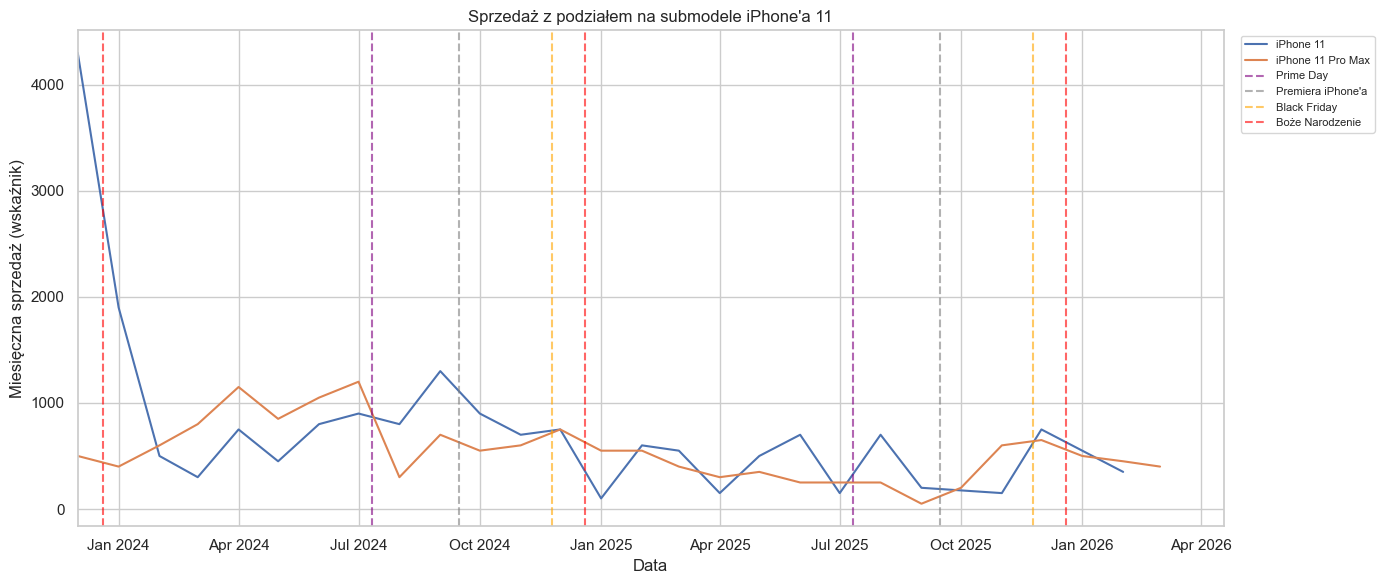

In [36]:
iphone15_ms_df = submodel_ms_df[(submodel_ms_df['generation_name'] == 'iPhone 15') & (submodel_ms_df['tier'].isin(['Base', 'Pro Max']))].copy()
iphone13_ms_df = submodel_ms_df[(submodel_ms_df['generation_name'] == 'iPhone 13') & (submodel_ms_df['tier'].isin(['Base', 'Pro Max']))].copy()
iphone11_ms_df = submodel_ms_df[(submodel_ms_df['generation_name'] == 'iPhone 11') & (submodel_ms_df['tier'].isin(['Base', 'Pro Max']))].copy()

def add_vlines(ax):
    ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day')
    ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Premiera iPhone\'a')
    ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday')
    ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Boże Narodzenie')
    for year in range(2024, 2026):
        ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

start = 4
for gen_df, title in [
    (iphone15_ms_df, 'submodele iPhone\'a 15'),
    (iphone13_ms_df, 'submodele iPhone\'a 13'),
    (iphone11_ms_df, 'submodele iPhone\'a 11'),
]:  
    start += 1
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.lineplot(data=gen_df, x='month_year', y='monthly_sold', hue='submodel_name', ax=ax)
    add_vlines(ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_title(f'Sprzedaż z podziałem na {title}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Miesięczna sprzedaż (wskaźnik)')
    ax.set_xlim(left=pd.Timestamp('2023-12-01'))
    plt.tight_layout()
    plt.savefig(f'wykres{start}.png', dpi=300, bbox_inches='tight')
    plt.show()

Różnice są tu znacznie wyraźniejsze i pozwalają sformułować nowe obserwacje.

## iPhone 15: dominacja Pro Maxa w drugim roku
Pro Max wykazuje sporą zmienność. 

Widać tu widoczny skok po premierze iPhone'a 16 (wrzesień 2024), i jeszcze większy wzrost po premierze 17 (wrzesień 2025). 

Kupujący zdają się czekać na koniec pierwszego roku, kiedy cena spada najmocniej, a premiera kolejnej generacji obniża ją jeszcze bardziej, tworząc dobry moment na zakup. 

Model bazowy iPhone'a 15 pozostaje względnie stabilny przez cały dostępny okres.

## iPhone 13: odwrócone role
Tu sytuacja jest odwrotna. 

Pro Max to stabilna kotwica, a model bazowy wyraźnie przoduje w sprzedaży i wykazuje dużo większą zmienność. Kupujący w tej generacji być może bardziej stawiają na koszty niż na możliwości flagowca.

## iPhone 11 jako przykład balansu
Model bazowy i Pro Max idą tu niemal łeb w łeb. 

Pamiętamy z analizy cenowej, że różnica cenowa kurczy się na końcu do okolic 100 USD, a Pro Max kosztuje blisko 300 USD. 

Przy takich cenach i różnicy cenowej dopłata za flagowiec staje się znacznie łatwiejszym wyborem.

---
# Kluczowe obserwacje

- **Marka Apple najlepiej utrzymuje wartość.** Pułap 50% pojawia się po raz pierwszy około 900 dni od premiery, a u konkurencji jest to około 500 dni dla Samsunga i 420 dla Google. Ta tendencja utrzymuje się przez cały cykl. Apple stabilizuje się średnio na poziomie 26-28% ceny premierowej, Samsung na około 16-17% a Google na pułapie 20%.

- **iPhone 13 to niekwestionowany król rynku wtórnego.** To najlepiej sprzedająca się generacja iPhone'a na rynku używanych telefonów na moment analizy.

- **Zakup 1-2 lata po premierze to świetna okazja.** Rok po premierze iPhone'y zachowują przeciętnie 70-75% ceny premierowej, a po dwóch latach około 50%. Technologia nie starzeje się znacznie przez ten okres czasu. Dane sprzedażowe, choć ograniczone, wydają się potwierdzać, że to realne okno zakupowe dla wielu osób, szczególnie w przypadku flagowców.

- **Niektóre niszowe warianty tracą wartość najszybciej.** Samsung Galaxy Edge i Google Pixel Pro Fold to przykłady komercyjnie nieudanych produktów. Oba notują jedne z najostrzejszych spadków w cenie i wyraźnie niski wolumen sprzedaży. Dokładne przyczyny są jedynie spekulacją i wymagałyby badań konsumenckich.

- **Starsze generacje kupują osoby szukające okazji.** W linii iPhone'a 13 to model bazowy prowadzi w sprzedaży, nie Pro Max. W przypadku iPhone'a 11, gdzie różnica cenowa mocno się skurczyła, Pro Max i model bazowy sprzedają się podobnie. Gdy dopłata za lepszy wariant staje się wystarczająco mała, kupujący po prostu sięgają po lepszy sprzęt.

- **Sprzedaż wszystkich marek zdaje się rosnąć w Q4.** Dla iPhone'ów koniec września przynosi premierę nowej generacji, po niej w listopadzie jest Black Friday i Boże Narodzenie w grudniu. Do potwierdzenia tego wzorca potrzeba jednak więcej obserwacji.